# DTSP-DR ：Phase 1 ~ Phase 5


# Phase 1：資料前處理與初始路線建立

本階段完成 instance 讀取、距離矩陣建立，以及所有參數設定。

## 1.1 資料路徑設定

In [225]:
import numpy as np
import math
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy
import matplotlib as mpl

# Windows 常見中文字型
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]  # 微軟正黑體
plt.rcParams["axes.unicode_minus"] = False  # 避免負號顯示成方塊

def find_project_root(start: Path = Path.cwd()) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "README.md").exists() and (p / "data" / "instances").exists():
            return p
    raise FileNotFoundError("找不到專案根目錄")

PROJECT_ROOT = find_project_root()
INSTANCE_DIR = PROJECT_ROOT / "data" / "instances"

files = sorted([f.name for f in INSTANCE_DIR.glob("*.txt")])
print(f"找到 {len(files)} 個 instance 檔案")
for f in files[:5]:
    print(f"  {f}")


找到 100 個 instance 檔案
  C101_100_75_1.txt
  C101_100_75_10.txt
  C101_100_75_2.txt
  C101_100_75_3.txt
  C101_100_75_4.txt


## 1.2 讀取 Instance

每個節點包含 `(id, x, y, r)`，其中 `r` 為 release time。
- `r=0` → initial order（truck 出發前就載好）
- `r>0` → dynamic order（途中才到達，包裹留在 depot，需 drone resupply）

In [226]:
def read_instance(filepath):
    customers = []
    depot = None
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    for line in lines:
        line = line.strip()
        if line == '' or line.startswith('ID'):
            continue
        parts = line.split()
        node = {'id': int(parts[0]), 'x': float(parts[1]),
                'y': float(parts[2]), 'r': float(parts[3])}
        if node['id'] == 0:
            depot = node
        else:
            customers.append(node)
    return depot, customers

# 測試
test_file = INSTANCE_DIR / "C101_100_75_2.txt"
depot, customers = read_instance(test_file)
print(f"Depot: ({depot['x']}, {depot['y']})")
print(f"Customers: {len(customers)}")

initial = [c for c in customers if c['r'] == 0]
dynamic = [c for c in customers if c['r'] > 0]
print(f"Initial (r=0): {len(initial)}, Dynamic (r>0): {len(dynamic)}")
print(f"DOD = {len(dynamic)/len(customers)*100:.0f}%")


Depot: (40.0, 50.0)
Customers: 100
Initial (r=0): 25, Dynamic (r>0): 75
DOD = 75%


## 1.3 精確 TSP（Gurobi MTZ Formulation）

用來：
1. 計算 $z_{TSP}$（所有 customer 的最短 tour 長度）→ 計算 delivery horizon $H$
2. 求 initial orders 的初始配送路線
##### TSP route generator :
1. 算一條路線有多長
2. 小規模用 Gurobi MILP 解 TSP
3. 大規模用 nearest-neighbor + 2-opt 快速解近似 TSP
4. 自動判斷要用哪一種方法



In [227]:
import gurobipy as gp
from gurobipy import GRB

def tour_length(tour, dist):
    """tour 是節點編號 list，例如 [0, 3, 1, 0]。"""
    if tour is None or len(tour) < 2:
        return float('inf')
    return float(sum(dist[tour[i], tour[i + 1]] for i in range(len(tour) - 1)))


def solve_tsp_nearest_neighbor_2opt(dist, node_ids, start=0, max_2opt_passes=30):
    """
    可擴充版 TSP heuristic：
    1. nearest neighbor 建初始 tour
    2. 2-opt local search 改善

    用途：
    - n=100 時，不要用 MTZ exact TSP 硬解。
    - 這個 heuristic 可以快速給 z_TSP 與 initial route 的近似值。
    """
    remaining = set(int(i) for i in node_ids)
    tour = [int(start)]
    current = int(start)

    while remaining:
        nxt = min(remaining, key=lambda j: float(dist[current, j]))
        tour.append(nxt)
        remaining.remove(nxt)
        current = nxt

    tour.append(int(start))

    # 2-opt improvement
    n = len(tour)
    improved = True
    passes = 0

    while improved and passes < max_2opt_passes:
        improved = False
        passes += 1

        for i in range(1, n - 2):
            a, b = tour[i - 1], tour[i]
            for k in range(i + 1, n - 1):
                c, d = tour[k], tour[k + 1]
                old = float(dist[a, b] + dist[c, d])
                new = float(dist[a, c] + dist[b, d])

                if new + 1e-9 < old:
                    tour[i:k + 1] = reversed(tour[i:k + 1])
                    improved = True

    return tour, tour_length(tour, dist)


def solve_tsp_exact(dist, node_ids, time_limit=None, mip_gap=None, fallback_heuristic=True):
    """
    Gurobi MTZ formulation 精確 TSP。

    注意：
    - MTZ exact TSP 不適合直接解 100-node instance。
    - 若 time_limit 到但已有 feasible incumbent，會回傳 incumbent。
    - 若沒有 feasible incumbent，且 fallback_heuristic=True，回傳 nearest-neighbor + 2-opt。
    """
    node_ids = list(node_ids)

    if len(node_ids) == 0:
        return [0, 0], 0.0

    nodes = [0] + list(node_ids)
    n = len(nodes)

    model = gp.Model("TSP")
    model.setParam('OutputFlag', 0)
    if time_limit is not None:
        model.setParam('TimeLimit', float(time_limit))
    if mip_gap is not None:
        model.setParam('MIPGap', float(mip_gap))

    x = {}
    for i in range(n):
        for j in range(n):
            if i != j:
                x[i, j] = model.addVar(vtype=GRB.BINARY, name=f"x_{i}_{j}")

    u = {}
    for i in range(1, n):
        u[i] = model.addVar(lb=1, ub=n-1, vtype=GRB.CONTINUOUS, name=f"u_{i}")

    model.setObjective(
        gp.quicksum(dist[nodes[i], nodes[j]] * x[i, j]
                    for i in range(n) for j in range(n) if i != j),
        GRB.MINIMIZE
    )

    for i in range(n):
        model.addConstr(gp.quicksum(x[i, j] for j in range(n) if j != i) == 1)

    for j in range(n):
        model.addConstr(gp.quicksum(x[i, j] for i in range(n) if i != j) == 1)

    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                model.addConstr(u[i] - u[j] + (n - 1) * x[i, j] <= n - 2)

    model.optimize()

    # OPTIMAL 或 TIME_LIMIT 但已有 incumbent，都取目前解。
    if model.SolCount > 0:
        tour = [0]
        current = 0
        used = {0}

        for _ in range(n - 1):
            next_candidates = [
                j for j in range(n)
                if j != current and x[current, j].X > 0.5
            ]
            if not next_candidates:
                break
            current = next_candidates[0]
            tour.append(current)
            used.add(current)

        tour.append(0)

        # 若因 time limit 造成抽 tour 不完整，改用 heuristic，避免後面 route 壞掉。
        if len(set(tour[:-1])) != n:
            if fallback_heuristic:
                return solve_tsp_nearest_neighbor_2opt(dist, node_ids)
            return None, None

        tour_nodes = [nodes[i] for i in tour]
        return tour_nodes, float(model.ObjVal)

    if fallback_heuristic:
        return solve_tsp_nearest_neighbor_2opt(dist, node_ids)

    return None, None


def solve_tsp_auto(dist, node_ids, exact_threshold=22, exact_time_limit=30, exact_mip_gap=0.01):
    """
    自動選 TSP 解法：
    - 小規模：用 Gurobi MTZ exact / near-exact
    - 大規模：用 nearest-neighbor + 2-opt heuristic

    目的：
    讓 C101_100_75_1 這類 100-customer instance 可以跑得動。
    """
    node_ids = list(node_ids)

    if len(node_ids) <= exact_threshold:
        tour, obj = solve_tsp_exact(
            dist,
            node_ids,
            time_limit=exact_time_limit,
            mip_gap=exact_mip_gap,
            fallback_heuristic=True
        )
        method = f"MTZ exact/limited, threshold={exact_threshold}, time_limit={exact_time_limit}s"
    else:
        tour, obj = solve_tsp_nearest_neighbor_2opt(dist, node_ids)
        method = "nearest-neighbor + 2-opt heuristic"

    return tour, obj, method


## 1.4 距離矩陣與 Instance 設定

- `compute_distance_matrix()`：歐氏距離，truck speed=1 所以距離=時間
- `setup_instance()`：整合所有參數，計算 $H = \zeta \cdot \beta \cdot z_{TSP}$
- Drone 參數：$|K|=2$, $Q=4$, $\delta=0$, drone speed=2（`drone_time = dist/2`）

In [228]:
def compute_distance_matrix(depot, customers):
    nodes = [depot] + customers
    n = len(nodes)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dx = nodes[i]['x'] - nodes[j]['x']
            dy = nodes[i]['y'] - nodes[j]['y']
            dist[i, j] = math.sqrt(dx**2 + dy**2)
    return dist


def setup_instance(filepath, zeta=1.0,
                   tsp_exact_threshold=22,
                   tsp_exact_time_limit= None,
                   tsp_exact_mip_gap=0.0):
    """
    建立 instance。

    v10 重點修正：
    - 原本 setup_instance() 會對全部 n=100 顧客呼叫 solve_tsp_exact(dist, all_ids)。
      100-node MTZ TSP 幾乎一定會卡很久。
    - 現在改用 solve_tsp_auto()：
      小規模用 MTZ；大規模用 nearest-neighbor + 2-opt heuristic。
    """
    depot, customers = read_instance(filepath)
    n = len(customers)
    dist = compute_distance_matrix(depot, customers)

    # Drone 飛行時間：depot -> customer i 的單程時間（drone speed = 2）
    drone_time = np.zeros(n + 1)
    for i in range(n):
        drone_time[i + 1] = dist[0, i + 1] / 2.0

    all_ids = list(range(1, n + 1))
    initial_orders = [i for i in all_ids if customers[i - 1]['r'] == 0]
    dynamic_orders = [i for i in all_ids if customers[i - 1]['r'] > 0]
    dynamic_orders.sort(key=lambda i: customers[i - 1]['r'])

    release = np.zeros(n + 1)
    for i in range(n):
        release[i + 1] = customers[i]['r']

    # Delivery horizon: H = zeta * beta * z_TSP
    # 大規模時 z_TSP 使用 heuristic 近似，避免 100-node exact MTZ 卡住。
    beta = 1.0
    _, z_tsp, z_tsp_method = solve_tsp_auto(
        dist,
        all_ids,
        exact_threshold=tsp_exact_threshold,
        exact_time_limit=tsp_exact_time_limit,
        exact_mip_gap=tsp_exact_mip_gap
    )

    H = zeta * beta * z_tsp

    return {
        'depot': depot, 'customers': customers, 'n': n,
        'dist': dist, 'drone_time': drone_time,
        'initial_orders': initial_orders, 'dynamic_orders': dynamic_orders,
        'release': release, 'z_tsp': z_tsp, 'H': H,
        'Q': 4, 'delta': 0, 'num_drones': 2, 'zeta': zeta,
        'z_tsp_method': z_tsp_method,
        'tsp_exact_threshold': tsp_exact_threshold,
    }

# 測試
inst = setup_instance(test_file, zeta=1.0)
print(f"n={inst['n']}, Initial: {inst['initial_orders']}, Dynamic: {inst['dynamic_orders']}")
print(f"z_TSP={inst['z_tsp']:.2f}, H={inst['H']:.2f}")
print(f"z_TSP method: {inst['z_tsp_method']}")
print(f"Q={inst['Q']}, delta={inst['delta']}, num_drones={inst['num_drones']}")


n=100, Initial: [1, 6, 8, 11, 18, 20, 23, 25, 26, 33, 39, 42, 49, 51, 57, 58, 60, 63, 64, 67, 74, 79, 84, 86, 90], Dynamic: [13, 16, 89, 68, 96, 35, 43, 73, 46, 54, 78, 77, 29, 5, 2, 80, 53, 66, 19, 4, 93, 3, 87, 91, 75, 94, 55, 31, 10, 72, 59, 22, 62, 99, 69, 24, 76, 97, 56, 83, 14, 36, 7, 70, 28, 50, 38, 47, 71, 15, 92, 21, 44, 45, 85, 65, 17, 100, 52, 98, 61, 81, 48, 41, 9, 27, 30, 40, 12, 37, 88, 34, 95, 32, 82]
z_TSP=508.99, H=508.99
z_TSP method: nearest-neighbor + 2-opt heuristic
Q=4, delta=0, num_drones=2


# Phase 2：Truck Route 動態更新

**更新觸發方式：Event-driven**（收到訂單才更新，不是固定時間段）。  
每個 dynamic order 的 release time 就是一個 decision epoch。

## 2.1 Arrival Schedule

把 dynamic orders 按 release time 排序，作為事件序列。

In [229]:
arrival_schedule = [(float(inst['release'][i]), int(i)) for i in inst['dynamic_orders']]
arrival_schedule.sort(key=lambda x: x[0])

print("=== Dynamic Order Arrival Schedule ===")
for t, cid in arrival_schedule:
    print(f"  t={t:6.1f} -> customer {cid}")


=== Dynamic Order Arrival Schedule ===
  t=  30.0 -> customer 13
  t=  36.0 -> customer 16
  t=  45.0 -> customer 89
  t=  59.0 -> customer 68
  t=  59.0 -> customer 96
  t=  69.0 -> customer 35
  t=  72.0 -> customer 43
  t=  84.0 -> customer 73
  t=  85.0 -> customer 46
  t=  87.0 -> customer 54
  t=  88.0 -> customer 78
  t= 103.0 -> customer 77
  t= 106.0 -> customer 29
  t= 107.0 -> customer 5
  t= 110.0 -> customer 2
  t= 113.0 -> customer 80
  t= 120.0 -> customer 53
  t= 121.0 -> customer 66
  t= 129.0 -> customer 19
  t= 138.0 -> customer 4
  t= 138.0 -> customer 93
  t= 142.0 -> customer 3
  t= 142.0 -> customer 87
  t= 149.0 -> customer 91
  t= 150.0 -> customer 75
  t= 165.0 -> customer 94
  t= 173.0 -> customer 55
  t= 175.0 -> customer 31
  t= 186.0 -> customer 10
  t= 186.0 -> customer 72
  t= 189.0 -> customer 59
  t= 195.0 -> customer 22
  t= 207.0 -> customer 62
  t= 208.0 -> customer 99
  t= 211.0 -> customer 69
  t= 216.0 -> customer 24
  t= 216.0 -> customer 76
  t

## 2.1A 視覺化：Dynamic Orders Arrival Timeline

這張圖用來檢查 dynamic orders 的到達順序。  
後續 online policy 會按照這個順序逐一做：

`advance state → cheapest insertion → DRP MILP → accept/reject`


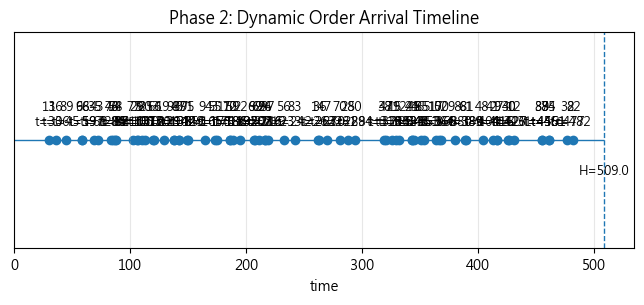

In [230]:

def plot_arrival_timeline(inst):
    dyn = sorted(inst['dynamic_orders'], key=lambda i: inst['release'][i])
    times = [float(inst['release'][i]) for i in dyn]

    fig, ax = plt.subplots(figsize=(8, 2.8))
    ax.hlines(1, 0, inst['H'], linewidth=1)
    ax.scatter(times, [1] * len(times), marker='o')

    for t, order in zip(times, dyn):
        ax.annotate(f'{order}\nt={t:.0f}', (t, 1), textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9)

    ax.axvline(inst['H'], linestyle='--', linewidth=1)
    ax.annotate(f'H={inst["H"]:.1f}', (inst['H'], 1), textcoords='offset points', xytext=(0, -25),
                ha='center', fontsize=9)

    ax.set_yticks([])
    ax.set_xlabel('time')
    ax.set_title('Phase 2: Dynamic Order Arrival Timeline')
    ax.set_xlim(left=0, right=max(inst['H'] * 1.05, max(times) * 1.05 if times else inst['H']))
    ax.grid(True, axis='x', alpha=0.3)
    plt.show()

plot_arrival_timeline(inst)


## 2.2 Helper Functions

### `route_remaining_time()`
計算 truck 走完剩餘 route 需要多少時間。

In [231]:
def route_remaining_time(future_route, time_to_next_node, dist):
    if len(future_route) == 0:
        return 0.0
    rem = float(time_to_next_node)
    for i in range(len(future_route) - 1):
        rem += float(dist[future_route[i], future_route[i + 1]])
    return rem


### `build_initial_truck_state()`
用 initial orders 解 TSP 得到初始路線，建立 t=0 的 truck state。

In [232]:
def build_initial_truck_state(inst):
    """
    建立 t=0 的 system state。

    v10 修正：
    - 原本 initial TSP 一律用 solve_tsp_exact()。
    - C101_100_75_1 會有約 25 個 initial orders；MTZ exact 也可能很慢。
    - 現在改用 solve_tsp_auto()，小規模 exact，大規模 heuristic。
    """
    full_tour, init_obj, init_tsp_method = solve_tsp_auto(
        inst['dist'],
        inst['initial_orders'],
        exact_threshold=22, # 初始訂單個數
        exact_time_limit=None,
        exact_mip_gap=0.0
    )

    future_route = full_tour[1:]  # 去掉起始 depot，通常最後仍含 depot 0

    if len(future_route) == 0:
        time_to_next_node = 0.0
    else:
        time_to_next_node = float(inst['dist'][0, future_route[0]])

    return {
        'current_time': 0.0,
        'future_route': list(future_route),
        'time_to_next_node': time_to_next_node,
        'completion_time': route_remaining_time(future_route, time_to_next_node, inst['dist']),

        # Order-state partition
        'accepted_orders': set(inst['initial_orders']),
        'delivered_orders': set(),
        'A_depot': set(),
        'L_truck': set(inst['initial_orders']),
        'O_drone': set(),

        # Vehicle-state
        'visited_nodes': [0],
        'drone_available_times': [0.0] * inst['num_drones'],
        'planned_sorties': [],
        'route_schedule': None,
        'realized_meetings': [],
        'initial_tsp_method': init_tsp_method,
        'initial_tsp_obj': float(init_obj),
    }

state = build_initial_truck_state(inst)
print(f"Initial route: [0] -> {state['future_route']}")
print(f"Completion: {state['completion_time']:.2f}")
print(f"Initial TSP method: {state['initial_tsp_method']}")
print(f"L_truck: {sorted(state['L_truck'])}, A_depot: {sorted(state['A_depot'])}")


Initial route: [0] -> [20, 25, 26, 23, 1, 6, 8, 11, 18, 39, 33, 51, 49, 42, 60, 58, 57, 64, 67, 63, 74, 79, 84, 86, 90, 0]
Completion: 323.41
Initial TSP method: nearest-neighbor + 2-opt heuristic
L_truck: [1, 6, 8, 11, 18, 20, 23, 25, 26, 33, 39, 42, 49, 51, 57, 58, 60, 63, 64, 67, 74, 79, 84, 86, 90], A_depot: []


## 1.5 視覺化：Instance 與 Initial Truck Route

這張圖用來確認 Phase 1 的資料與 initial route 是否合理：

- `depot` 是起點與終點。
- 初始訂單會在 t=0 裝上 truck。
- dynamic orders 則會在後續 release time 到達。
- 折線是初始 TSP route，作為 online policy 的起始配送路線。


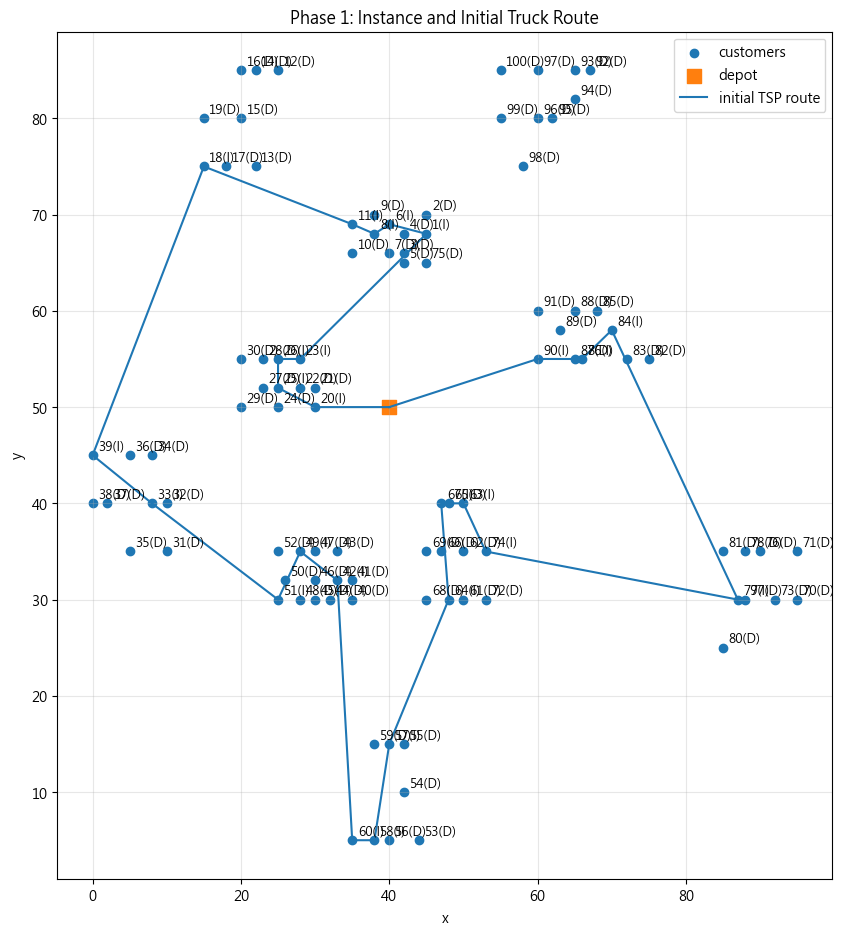

In [233]:

def _node_xy(inst, node):
    # 回傳 node 的座標；node=0 代表 depot。
    if node == 0:
        return inst['depot']['x'], inst['depot']['y']
    c = inst['customers'][node - 1]
    return c['x'], c['y']

def plot_instance_and_initial_route(inst, state=None):
    if state is None:
        state = build_initial_truck_state(inst)

    fig, ax = plt.subplots(figsize=(10, 11))

    # All customers
    xs = [c['x'] for c in inst['customers']]
    ys = [c['y'] for c in inst['customers']]
    ax.scatter(xs, ys, marker='o', label='customers')

    # Depot
    dx, dy = _node_xy(inst, 0)
    ax.scatter([dx], [dy], marker='s', s=100, label='depot')

    # Initial / dynamic labels
    initial = set(inst['initial_orders'])
    for i, c in enumerate(inst['customers'], start=1):
        tag = 'I' if i in initial else 'D'
        ax.annotate(f'{i}({tag})', (c['x'], c['y']), textcoords='offset points', xytext=(4, 4), fontsize=9)

    # Initial route
    route = [0] + list(state['future_route'])
    rx = [_node_xy(inst, n)[0] for n in route]
    ry = [_node_xy(inst, n)[1] for n in route]
    ax.plot(rx, ry, linewidth=1.5, label='initial TSP route')

    ax.set_title('Phase 1: Instance and Initial Truck Route')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

plot_instance_and_initial_route(inst, state)


### `advance_truck_state_to_time()`
把 truck 推進到指定時間，追蹤經過了哪些節點。
##### 其主要功能包括：

1. 判斷 drone sortie 是否已起飛、會合或返回。
2. 鎖定已起飛 drone 對應的 truck route prefix。
3. 更新 orders 在 depot、drone、truck 或 delivered 的狀態。
4. 推進 truck 沿著 future route 移動。
5. 將已拜訪 customer 標記為 delivered。
6. 清理不合理的 order-state 重疊。
7. 確保每次 dynamic order 到達時，系統狀態是正確的。

In [234]:

def is_in_transit_sortie(sortie, current_time, eps=1e-9):
    """True if the drone has launched but has not yet met the truck."""
    if sortie.get('transferred', False):
        return False
    return (float(sortie['launch_time']) <= float(current_time) + eps and
            float(current_time) < float(sortie['meeting_time']) - eps)


def is_launched_active_sortie(sortie, current_time, eps=1e-9):
    """True if the sortie has launched and the drone has not returned to the depot."""
    return (float(sortie['launch_time']) <= float(current_time) + eps and
            float(current_time) < float(sortie['return_time']) - eps)


def get_in_transit_sorties(state, eps=1e-9):
    """
    取得已起飛但尚未 rendezvous 的 sorties。

    這些 sorties 在下一次 decision epoch 中不可撤銷：
    - orders 不再屬於 A_depot，不可重新分配。
    - drone 在 return_time 前不可再被派遣。
    - truck route 必須固定到 meeting_node。
    """
    t = float(state.get('current_time', 0.0))
    return [deepcopy(s) for s in state.get('planned_sorties', [])
            if is_in_transit_sortie(s, t, eps=eps)]


def get_launched_active_sorties(state, eps=1e-9):
    """取得已起飛且尚未返回 depot 的 sorties，包含 in-transit 與 returning。"""
    t = float(state.get('current_time', 0.0))
    return [deepcopy(s) for s in state.get('planned_sorties', [])
            if is_launched_active_sortie(s, t, eps=eps)]


def get_route_prefix_lock_index(state, eps=1e-9):
    """
    回傳 truck route 必須鎖住到哪個 index。

    若 drone 已起飛前往 meeting_node，truck route 在 meeting_node 以前不可改動。
    因此新訂單只能插在 lock_index 之後。

    Returns
    -------
    lock_index : int
        -1 表示沒有 in-transit lock；>=0 表示 future_route[0:lock_index+1] 必須固定。
    lock_nodes : list[int]
        被 in-transit drone 鎖住的 rendezvous nodes。
    """
    route = list(state.get('future_route', []))
    lock_index = -1
    lock_nodes = []

    for sortie in get_in_transit_sorties(state, eps=eps):
        m = int(sortie['meeting_node'])
        lock_nodes.append(m)
        if m not in route:
            # 狀態不一致：drone 已起飛，但 truck residual route 已沒有 rendezvous node。
            return None, lock_nodes
        lock_index = max(lock_index, route.index(m))

    return lock_index, lock_nodes


def compute_schedule_with_fixed_sorties(current_time, future_route, time_to_next_node,
                                        dist, fixed_sorties, eps=1e-9):
    """
    在沒有新的 depot orders 時，仍需讓 truck schedule 尊重已起飛 drone 的固定 rendezvous。

    這不是重新最佳化，只是把已起飛 sortie 的 meeting_departure 當成下界：
    truck 若太早到 rendezvous node，就等待到 fixed meeting_departure。
    """
    route = list(future_route)
    if len(route) == 0:
        return float(current_time), {}, True

    _, baseline_dep = compute_node_departure_times(
        current_time, route, time_to_next_node, dist)
    schedule = [float(x) for x in baseline_dep]

    fixed = sorted(fixed_sorties, key=lambda s: float(s['meeting_departure']))
    for sortie in fixed:
        node = int(sortie['meeting_node'])
        if node not in route:
            return float('inf'), {}, False
        pos = route.index(node)
        required = float(sortie['meeting_departure'])
        if schedule[pos] < required - eps:
            delay = required - schedule[pos]
            for idx in range(pos, len(schedule)):
                schedule[idx] += delay

    T_values = {i: float(t) for i, t in enumerate(schedule)}
    return float(schedule[-1]), T_values, True



def sanitize_order_partitions(state):
    """
    修正並維持 order-state partition 一致性。

    每個已接受訂單理論上只能落在以下其中一個集合：
    delivered_orders / L_truck / A_depot / O_drone

    若訂單已 delivered，就不應該還留在 A_depot、L_truck 或 O_drone。
    這個函數用於每次狀態推進後清理 stale state，避免 final summary
    出現「已送達但仍在 depot」的矛盾。
    """
    s = deepcopy(state)

    delivered = set(s.get('delivered_orders', set()))
    L_truck = set(s.get('L_truck', set()))
    A_depot = set(s.get('A_depot', set()))
    O_drone = set(s.get('O_drone', set()))

    # delivered 優先：已送達者不能再留在任何位置集合。
    L_truck -= delivered
    A_depot -= delivered
    O_drone -= delivered

    # 若同一 order 同時出現在多個未送達位置，依照實物流向保留較後階段：
    # O_drone > L_truck > A_depot
    A_depot -= (L_truck | O_drone)
    L_truck -= O_drone

    s['delivered_orders'] = delivered
    s['L_truck'] = L_truck
    s['A_depot'] = A_depot
    s['O_drone'] = O_drone
    return s


def check_state_consistency(state, label=""):
    """
    印出 order-state partition 是否有重疊。
    Debug / final summary 前使用。
    """
    delivered = set(state.get('delivered_orders', set()))
    L_truck = set(state.get('L_truck', set()))
    A_depot = set(state.get('A_depot', set()))
    O_drone = set(state.get('O_drone', set()))

    pairs = [
        ("Delivered ∩ L_truck", delivered & L_truck),
        ("Delivered ∩ A_depot", delivered & A_depot),
        ("Delivered ∩ O_drone", delivered & O_drone),
        ("L_truck ∩ A_depot", L_truck & A_depot),
        ("L_truck ∩ O_drone", L_truck & O_drone),
        ("A_depot ∩ O_drone", A_depot & O_drone),
    ]

    print(f"\n=== State consistency check {label} ===")
    ok = True
    for name, overlap in pairs:
        if overlap:
            ok = False
            print(f"[ERROR] {name}: {sorted(overlap)}")

    if ok:
        print("OK: order-state partitions are disjoint.")

    if len(A_depot) > 0 and len(state.get('planned_sorties', [])) == 0:
        print(f"[WARNING] A_depot not empty but planned_sorties = 0: {sorted(A_depot)}")

    return ok

def advance_truck_state_to_time(state, new_time, inst_or_dist, eps=1e-9):
    """
    將 system state 推進到 new_time。

    v5 修正版：
    - 尚未起飛的 planned sortie 不保留，代表可在下一個 DRP 被重新規劃。
    - 已起飛但尚未 rendezvous 的 sortie 保留為 in-transit，不可撤銷。
    - 已 rendezvous 但 drone 尚未回 depot 的 sortie 保留為 returning，只鎖住 drone availability。
    - transferred=True 可避免同一批 orders 在下一個 decision epoch 被重複加入 L_truck。
    """
    inst = inst_or_dist if isinstance(inst_or_dist, dict) else None
    dist = inst_or_dist['dist'] if isinstance(inst_or_dist, dict) else inst_or_dist

    if new_time < state['current_time'] - eps:
        raise ValueError("new_time 不能早於目前時間")

    s = deepcopy(state)
    old_time = float(s['current_time'])
    new_time = float(new_time)

    # ------------------------------------------------------------
    # 1) Drone / order state transition
    # ------------------------------------------------------------
    if inst is not None:
        A_depot = set(s.get('A_depot', set()))
        L_truck = set(s.get('L_truck', set()))
        O_drone = set(s.get('O_drone', set()))
        drone_avail = list(s.get('drone_available_times', [0.0] * inst['num_drones']))
        meeting_log = list(s.get('realized_meetings', []))

        active_sorties = []
        for sortie in s.get('planned_sorties', []):
            already_transferred = bool(sortie.get('transferred', False))
            orders = set(sortie.get('orders', []))
            drone_id = int(sortie['drone'])
            launch_t = float(sortie['launch_time'])
            meeting_t = float(sortie['meeting_time'])
            return_t = float(sortie['return_time'])

            # 已回 depot：不再保留。
            if return_t <= new_time + eps:
                if not already_transferred and launch_t < new_time - eps:
                    # 時間直接跳過整個 sortie：一次完成 depot -> truck 的轉移。
                    A_depot -= orders
                    O_drone -= orders
                    L_truck |= orders
                    meeting_log.append({
                        'drone': drone_id,
                        'meeting_node': int(sortie['meeting_node']),
                        'meeting_time': meeting_t,
                        'return_time': return_t,
                        'orders': sorted(orders),
                        'source': 'realized'
                    })
                drone_avail[drone_id] = max(drone_avail[drone_id], return_t)
                continue

            # 尚未起飛：可重規劃，因此不保留；orders 仍在 A_depot。
            if launch_t >= new_time - eps:
                continue

            # 已起飛：orders 不再在 depot。
            A_depot -= orders

            if already_transferred:
                # 已 rendezvous，drone returning：只保留 drone 占用狀態，不再帶 orders。
                active_sortie = deepcopy(sortie)
                active_sortie['orders'] = []
                active_sortie['transferred'] = True
                active_sorties.append(active_sortie)
                drone_avail[drone_id] = max(drone_avail[drone_id], return_t)
                continue

            if meeting_t > new_time + eps:
                # 已起飛但尚未 rendezvous：in-transit，必須在下一次 DRP 中固定。
                O_drone |= orders
                active_sortie = deepcopy(sortie)
                active_sortie['transferred'] = False
                active_sorties.append(active_sortie)
                drone_avail[drone_id] = max(drone_avail[drone_id], return_t)
                continue

            # 已 rendezvous：orders 轉到 truck，並標記 transferred。
            O_drone -= orders
            L_truck |= orders
            meeting_log.append({
                'drone': drone_id,
                'meeting_node': int(sortie['meeting_node']),
                'meeting_time': meeting_t,
                'return_time': return_t,
                'orders': sorted(orders),
                'source': 'realized'
            })
            active_sortie = deepcopy(sortie)
            active_sortie['orders'] = []
            active_sortie['transferred'] = True
            active_sorties.append(active_sortie)
            drone_avail[drone_id] = max(drone_avail[drone_id], return_t)

        s['A_depot'] = A_depot
        s['L_truck'] = L_truck
        s['O_drone'] = O_drone
        s['planned_sorties'] = active_sorties
        s['drone_available_times'] = drone_avail
        s['realized_meetings'] = meeting_log

    # ------------------------------------------------------------
    # 2) Truck movement
    # ------------------------------------------------------------
    route = list(s.get('future_route', []))
    visited = list(s.get('visited_nodes', []))
    delivered = set(s.get('delivered_orders', set()))
    L_truck = set(s.get('L_truck', set()))

    schedule = s.get('route_schedule', None)

    # 若有 DRP 回寫的 absolute route schedule，優先用 schedule 推進。
    if schedule is not None and len(schedule) == len(route):
        schedule = list(schedule)

        while route and schedule and schedule[0] <= new_time + eps:
            reached = route.pop(0)
            schedule.pop(0)
            visited.append(reached)

            if reached != 0:
                delivered.add(reached)
                L_truck.discard(reached)
                # v12 fix: 已送達者不可再留在 depot/drone stale sets
                s['A_depot'] = set(s.get('A_depot', set())) - {reached}
                s['O_drone'] = set(s.get('O_drone', set())) - {reached}

        time_to_next = 0.0 if not route else max(0.0, schedule[0] - new_time)
        completion_time = new_time if not route else float(schedule[-1])

        s['current_time'] = new_time
        s['future_route'] = route
        s['time_to_next_node'] = time_to_next
        s['visited_nodes'] = visited
        s['delivered_orders'] = delivered
        s['L_truck'] = L_truck
        s['route_schedule'] = schedule if route else None
        s['completion_time'] = completion_time
        s = sanitize_order_partitions(s)
        s['locked_prefix_until'], s['locked_meeting_nodes'] = get_route_prefix_lock_index(s)
        return s

    # 沒有 schedule 時，使用 truck-only travel time 推進。
    delta_t = float(new_time - old_time)
    time_to_next = float(s.get('time_to_next_node', 0.0))

    while delta_t > eps and len(route) > 0:
        if delta_t + eps >= time_to_next:
            delta_t -= time_to_next
            reached = route.pop(0)
            visited.append(reached)

            if reached != 0:
                delivered.add(reached)
                L_truck.discard(reached)
                # v12 fix: 已送達者不可再留在 depot/drone stale sets
                s['A_depot'] = set(s.get('A_depot', set())) - {reached}
                s['O_drone'] = set(s.get('O_drone', set())) - {reached}

            if len(route) == 0:
                time_to_next = 0.0
                break
            time_to_next = float(dist[reached, route[0]])
        else:
            time_to_next -= delta_t
            delta_t = 0.0

    s['current_time'] = new_time
    s['future_route'] = route
    s['time_to_next_node'] = time_to_next
    s['visited_nodes'] = visited
    s['delivered_orders'] = delivered
    s['L_truck'] = L_truck
    s['route_schedule'] = None
    s['completion_time'] = s['current_time'] + route_remaining_time(route, time_to_next, dist)
    s = sanitize_order_partitions(s)
    s['locked_prefix_until'], s['locked_meeting_nodes'] = get_route_prefix_lock_index(s)
    return s


### `cheapest_insertion_residual_route()`
把新節點插入 residual route 中 cost 最小的位置。  
`keep_first_fixed=True`：truck 正在前往的下一個節點不能改。

In [235]:

def cheapest_insertion_residual_route(future_route, new_node, dist,
                                      keep_first_fixed=True,
                                      min_insert_pos=None):
    """
    把新節點插入 residual route 中 cost 最小的位置。

    v5 修正版：
    - 若 future_route 為 [0] 或空，表示 truck 已經只剩回 depot / 已回 depot，
      在本文基本 DTSP-DR 設定下不允許重新出發。
    - min_insert_pos 用於 in-transit drone locking：
      若 drone 已起飛要在某個 node rendezvous，新訂單只能插在該 node 之後。
    """
    future_route = list(future_route)

    if new_node in future_route:
        raise ValueError(f"customer {new_node} 已在 route 中")

    if len(future_route) == 0 or future_route == [0]:
        return None, float('inf'), None

    if future_route[-1] != 0:
        raise ValueError("future_route 必須以 depot 0 結尾")

    default_start = 1 if keep_first_fixed else 0
    if min_insert_pos is None:
        start_pos = default_start
    else:
        start_pos = max(default_start, int(min_insert_pos))

    # 可插入的位置 p 代表插在 future_route[p-1] 與 future_route[p] 中間；
    # p 最大為 len(future_route)-1，也就是插在最後 depot 前。
    if start_pos >= len(future_route):
        return None, float('inf'), None

    best_delta = float('inf')
    best_route = None
    best_pos = None

    for p in range(start_pos, len(future_route)):
        prev_node = future_route[p - 1]
        next_node = future_route[p]
        delta = (float(dist[prev_node, new_node]) + float(dist[new_node, next_node])
                 - float(dist[prev_node, next_node]))
        candidate = future_route[:p] + [new_node] + future_route[p:]
        if delta < best_delta:
            best_delta = delta
            best_route = candidate
            best_pos = p

    return best_route, best_delta, best_pos


### `build_candidate_after_insertion()`
組合 insertion 結果，建立 candidate state。

In [236]:

def build_candidate_after_insertion(state, new_order, inst):
    """
    Phase 2 只產生 candidate route，不直接接受訂單。
    真正 accept/reject 由 Phase 5 的 DRP + threshold 決定。

    v5 補強：
    若存在 in-transit drone，則 truck route 會鎖定到 rendezvous node；
    新訂單只能插在 locked prefix 之後。
    """
    old_route = list(state['future_route'])
    old_completion = float(state['completion_time'])

    lock_index, lock_nodes = get_route_prefix_lock_index(state)
    if lock_index is None:
        info = {
            'new_order': int(new_order),
            'old_route': old_route,
            'new_route': None,
            'insert_pos': None,
            'old_completion': old_completion,
            'new_completion': float('inf'),
            'delta_insertion': float('inf'),
            'feasible_by_H': False,
            'reason': 'in_transit_meeting_node_missing',
            'locked_prefix_until': None,
            'locked_meeting_nodes': lock_nodes,
        }
        return None, info

    min_insert_pos = None if lock_index < 0 else lock_index + 1

    new_route, insertion_delta, insert_pos = cheapest_insertion_residual_route(
        future_route=old_route,
        new_node=int(new_order),
        dist=inst['dist'],
        keep_first_fixed=True,
        min_insert_pos=min_insert_pos)

    if new_route is None:
        reason = 'truck_already_returning_to_depot'
        if min_insert_pos is not None:
            reason = 'no_insert_position_after_locked_prefix'
        info = {
            'new_order': int(new_order),
            'old_route': old_route,
            'new_route': None,
            'insert_pos': None,
            'old_completion': old_completion,
            'new_completion': float('inf'),
            'delta_insertion': float('inf'),
            'feasible_by_H': False,
            'reason': reason,
            'locked_prefix_until': lock_index,
            'locked_meeting_nodes': lock_nodes,
        }
        return None, info

    new_completion = state['current_time'] + route_remaining_time(
        new_route, state['time_to_next_node'], inst['dist'])

    candidate = deepcopy(state)
    candidate['future_route'] = new_route
    candidate['completion_time'] = new_completion
    candidate['accepted_orders'] = set(candidate['accepted_orders']) | {int(new_order)}
    candidate['route_schedule'] = None  # route changed; must be recomputed by DRP
    candidate['locked_prefix_until'] = lock_index
    candidate['locked_meeting_nodes'] = lock_nodes

    info = {
        'new_order': int(new_order),
        'old_route': old_route,
        'new_route': new_route,
        'insert_pos': int(insert_pos),
        'old_completion': old_completion,
        'new_completion': new_completion,
        'delta_insertion': float(insertion_delta),
        'feasible_by_H': bool(new_completion <= inst['H']),
        'reason': None if new_completion <= inst['H'] else 'truck_completion_exceeds_H',
        'locked_prefix_until': lock_index,
        'locked_meeting_nodes': lock_nodes,
    }
    return candidate, info


## 2.3 Phase 2 模擬（baseline only）

⚠️ **此段只作為 truck-only baseline 。**

正式論文流程中，Phase 2 的 cheapest insertion 只產生 candidate route；  
新訂單是否接受，必須交給 Phase 5 的 DRP + acceptance threshold 判斷。


In [237]:
state = build_initial_truck_state(inst)
phase2_log = []

for arrival_time, new_order in arrival_schedule:
    state = advance_truck_state_to_time(state, arrival_time, inst)
    candidate, info = build_candidate_after_insertion(state, new_order, inst)

    accepted = (candidate is not None) and info['feasible_by_H']  # baseline only
    phase2_log.append({
        'time': arrival_time,
        'order': new_order,
        'accepted_by_truck_only': accepted,
        'completion': info['new_completion'],
        'reason': info.get('reason'),
    })

    if accepted:
        state = candidate

print("=== Phase 2 truck-only baseline（非正式 policy）===")
for row in phase2_log:
    print(f"t={row['time']:6.1f}, order={row['order']:2d}, "
          f"truck-only accepted={row['accepted_by_truck_only']}, "
          f"completion={row['completion']:.2f}, reason={row['reason']}")


=== Phase 2 truck-only baseline（非正式 policy）===
t=  30.0, order=13, truck-only accepted=True, completion=323.85, reason=None
t=  36.0, order=16, truck-only accepted=True, completion=338.23, reason=None
t=  45.0, order=89, truck-only accepted=True, completion=340.72, reason=None
t=  59.0, order=68, truck-only accepted=True, completion=342.53, reason=None
t=  59.0, order=96, truck-only accepted=True, completion=382.97, reason=None
t=  69.0, order=35, truck-only accepted=True, completion=389.69, reason=None
t=  72.0, order=43, truck-only accepted=True, completion=391.86, reason=None
t=  84.0, order=73, truck-only accepted=True, completion=399.71, reason=None
t=  85.0, order=46, truck-only accepted=True, completion=402.56, reason=None
t=  87.0, order=54, truck-only accepted=True, completion=404.15, reason=None
t=  88.0, order=78, truck-only accepted=True, completion=404.15, reason=None
t= 103.0, order=77, truck-only accepted=True, completion=404.15, reason=None
t= 106.0, order=29, truck-onl

# Phase 3 + 4：DRP 邏輯驗證與 Gurobi MILP

**對應論文：Section 5.3 — Drone Resupply Problem (DRP)**

## 論文的配送流程

1. Truck 出發後 **不會回 depot 拿貨**
2. Dynamic order 被接受 → 包裹留在 depot → 成為 **depot order**
3. Drone 從 depot 帶包裹飛到 truck route 上的 **meeting node** 與 truck 會合
4. Drone 在 meeting node 卸貨到 truck 上（耗時 δ）→ 飛回 depot
5. Truck 繼續沿 route 配送到客戶家

**DRP 的任務：** 給定固定的 truck route 和 depot orders，  
決定 drone 在哪些 meeting nodes 與 truck 會合，使 completion time 最小。


## 3.1 Drone 參數確認

In [238]:
print("=== Drone 參數（論文 Section 3）===")
print(f"|K| = {inst['num_drones']}, Q = {inst['Q']}, delta = {inst['delta']}")
print(f"Truck speed = 1, Drone speed = 2")
print()

print("=== Drone 單程飛行時間（depot -> customer）===")
for i in range(1, inst['n'] + 1):
    print(f"  Customer {i:2d}: dist={inst['dist'][0][i]:6.2f}, "
          f"drone_time={inst['drone_time'][i]:6.2f} (=dist/2)")


=== Drone 參數（論文 Section 3）===
|K| = 2, Q = 4, delta = 0
Truck speed = 1, Drone speed = 2

=== Drone 單程飛行時間（depot -> customer）===
  Customer  1: dist= 18.68, drone_time=  9.34 (=dist/2)
  Customer  2: dist= 20.62, drone_time= 10.31 (=dist/2)
  Customer  3: dist= 16.12, drone_time=  8.06 (=dist/2)
  Customer  4: dist= 18.11, drone_time=  9.06 (=dist/2)
  Customer  5: dist= 15.13, drone_time=  7.57 (=dist/2)
  Customer  6: dist= 19.00, drone_time=  9.50 (=dist/2)
  Customer  7: dist= 16.00, drone_time=  8.00 (=dist/2)
  Customer  8: dist= 18.11, drone_time=  9.06 (=dist/2)
  Customer  9: dist= 20.10, drone_time= 10.05 (=dist/2)
  Customer 10: dist= 16.76, drone_time=  8.38 (=dist/2)
  Customer 11: dist= 19.65, drone_time=  9.82 (=dist/2)
  Customer 12: dist= 38.08, drone_time= 19.04 (=dist/2)
  Customer 13: dist= 30.81, drone_time= 15.40 (=dist/2)
  Customer 14: dist= 39.36, drone_time= 19.68 (=dist/2)
  Customer 15: dist= 36.06, drone_time= 18.03 (=dist/2)
  Customer 16: dist= 40.31, dro

## 3.2 Truck Node Departure Times

計算 truck 在 route 各節點的到達時間。  
DRP 需要這個資訊來判斷 drone 和 truck 誰先到 meeting node。

In [239]:
def compute_node_departure_times(current_time, future_route, time_to_next_node, dist):
    """計算 truck 在 future_route 各節點的 departure time（baseline，不含 drone 等待）。"""
    if len(future_route) == 0:
        return {}, []
    node_dep = {}
    pos_dep = []
    t = current_time + time_to_next_node
    node_dep[future_route[0]] = t
    pos_dep.append(t)
    for i in range(1, len(future_route)):
        t += dist[future_route[i - 1]][future_route[i]]
        node_dep[future_route[i]] = t
        pos_dep.append(t)
    return node_dep, pos_dep

# 測試
test_s = build_initial_truck_state(inst)
nd, pd = compute_node_departure_times(
    test_s['current_time'], test_s['future_route'],
    test_s['time_to_next_node'], inst['dist'])
print("=== Truck 到達時間（初始 route）===")
for pos, node in enumerate(test_s['future_route']):
    label = 'depot' if node == 0 else f'cust {node}'
    print(f"  Pos {pos} ({label:8s}): {pd[pos]:.2f}")


=== Truck 到達時間（初始 route）===
  Pos 0 (cust 20 ): 10.00
  Pos 1 (cust 25 ): 15.39
  Pos 2 (cust 26 ): 18.39
  Pos 3 (cust 23 ): 21.39
  Pos 4 (cust 1  ): 42.79
  Pos 5 (cust 6  ): 47.89
  Pos 6 (cust 8  ): 50.12
  Pos 7 (cust 11 ): 53.28
  Pos 8 (cust 18 ): 74.16
  Pos 9 (cust 39 ): 107.71
  Pos 10 (cust 33 ): 117.14
  Pos 11 (cust 51 ): 136.86
  Pos 12 (cust 49 ): 142.69
  Pos 13 (cust 42 ): 148.52
  Pos 14 (cust 60 ): 175.60
  Pos 15 (cust 58 ): 178.60
  Pos 16 (cust 57 ): 188.80
  Pos 17 (cust 64 ): 205.80
  Pos 18 (cust 67 ): 215.85
  Pos 19 (cust 63 ): 218.85
  Pos 20 (cust 74 ): 224.68
  Pos 21 (cust 79 ): 259.04
  Pos 22 (cust 84 ): 291.80
  Pos 23 (cust 86 ): 296.80
  Pos 24 (cust 90 ): 302.80
  Pos 25 (depot   ): 323.41


## 3.3 DRP MILP（論文 Section 5.3, Constraints 53–64）

**決策變數：**
- $u_{ki} \in \{0,1\}$：drone $k$ 是否在 position $i$ resupply
- $y_{ji} \in \{0,1\}$：sortie $j$ 是否在 position $i$ 發生
- $T_i \geq 0$：truck 離開 position $i$ 的時間

**目標：** $\min T_m$（truck 回到 depot 的時間）

**Constraints：**

| Eq. | 說明 |
|-----|------|
| (53) | 每個 sortie 恰在一個位置 |
| (54) | Symmetry breaking |
| (55) | Linking y 和 u |
| — | 每個位置最多一架 drone |
| (56) | 第一個位置 departure time |
| (57)(58) | 後續位置 departure（含/不含 δ）|
| (59) | $T_i \geq (a_k + \tau_{0,v_i}^D + \delta) \cdot u_{ki}$ |
| (60) | 同一架 drone 連續 sortie |
| (64) | Valid inequality |

**注意 Constraint (59) 關於 drone 出發時間：**  
$a_k$ 是 drone $k$ 的 available time。在模擬中我們設定  
$a_k = \max(\text{上次飛回 depot 的時間}, \text{訂單到達時間})$，  
因為訂單到達前系統不知道有這筆訂單，drone 不可能提前出發。  
MILP 本身不決定 drone 幾點起飛，只確保 truck 在 meeting node 的停留時間足夠。


## 3.3A Planned Sorties 重規劃與 In-transit Locking

本版將每一趟 planned sortie 用三個事件時間管理：

| Sortie 狀態 | 判斷條件 | 本版處理方式 |
|---|---|---|
| 尚未起飛 | `current_time < launch_time` | 可取消，可由下一次 DRP 重新規劃；orders 留在 `A_depot`。 |
| 已起飛、尚未會合 | `launch_time <= current_time < meeting_time` | 視為 **fixed sortie**，不可撤銷；orders 移到 `O_drone`；truck route 鎖定到 rendezvous node。 |
| 已會合、尚未回 depot | `meeting_time <= current_time < return_time` | orders 已轉到 `L_truck`；drone 還不可用；以 `transferred=True` 防止重複轉移。 |
| 已回 depot | `current_time >= return_time` | sortie 從 `planned_sorties` 移除，`drone_available_time` 更新。 |

本版補齊兩層 locking：

1. **Route insertion locking**：若 drone 已起飛前往某個 rendezvous node，新訂單只能插在該 node 之後，truck 到 rendezvous 前的 route 不可改動。
2. **DRP prefix timing lock**：下一次 DRP 不只鎖住該 rendezvous position，也禁止新的 drone sortie 安排在 locked prefix 內。也就是若 fixed sortie 鎖到 position `p`，新的 meeting position 只能選 `i > p`。

這樣可以避免一個常見錯誤：drone 已經飛往 position 2，但新的 DRP 又在 position 0 或 1 插入另一趟 resupply，導致 truck 到原本 rendezvous 的時間被改變。

這仍是事件式簡化，而不是連續時間軌跡模擬；但已能符合論文中「未起飛可重規劃、已起飛不可撤銷」的核心邏輯。


In [240]:

def solve_drp(future_route, current_time, time_to_next_node,
              depot_orders, drone_available, inst, fixed_sorties=None,
              drp_time_limit=5, drp_mip_gap=0.01):
    """
    論文 Section 5.3 的 DRP MILP（修正版）。

    已補齊：in-transit planned sortie locking
    1. depot_orders：尚未起飛、仍在 depot 的 orders，由本次 DRP 重新規劃。
    2. fixed_sorties：已起飛但尚未 rendezvous 的 sorties，不可撤銷。
       - 其 meeting_node 必須仍在 future_route 中。
       - truck departure time at meeting_node 必須 >= fixed meeting_departure。
       - 該 meeting position 不可再安排新的 sortie。
       - fixed rendezvous 以前的 route prefix 也不可安排新的 drone meeting。
       - drone_available 已在 state transition 中被設為 return_time，因此該 drone 回 depot 前不可再派遣。
    3. order-to-sortie assignment：確保每個 depot order 在其 customer 被拜訪前補給到 truck。
    """
    dist = inst['dist']
    drone_time = inst['drone_time']
    delta = float(inst['delta'])
    Q = int(inst['Q'])
    num_drones = int(inst['num_drones'])

    route = list(future_route)
    orders = sorted(int(o) for o in depot_orders)
    fixed_sorties = [deepcopy(s) for s in (fixed_sorties or [])]

    if len(route) == 0:
        return (float(current_time), [], True, {}) if len(orders) == 0 and len(fixed_sorties) == 0 else (float('inf'), [], False, {})

    if route == [0]:
        return float('inf'), [], False, {}

    if route[-1] != 0:
        raise ValueError("future_route 必須以 depot 0 結尾")

    n_route = len(route)

    # 固定已起飛 sortie 的 meeting position，並記錄 locked prefix。
    #
    # 若 drone 已經起飛且要在 route position p 會合，
    # 則 truck route 在 position p 以前不可被新的 resupply event 改變。
    # 因此新的 drone meeting position 只能選在 p 之後。
    fixed_positions = set()
    fixed_departure_lb = {}
    locked_prefix_until = -1
    for fs in fixed_sorties:
        m = int(fs['meeting_node'])
        if m not in route:
            return float('inf'), [], False, {}
        pos = route.index(m)
        if route[pos] == 0:
            return float('inf'), [], False, {}
        fixed_positions.add(pos)
        locked_prefix_until = max(locked_prefix_until, pos)
        fixed_departure_lb[pos] = max(
            fixed_departure_lb.get(pos, 0.0),
            float(fs['meeting_departure'])
        )

    # 沒有新的 depot orders：只需要根據固定 sortie 修正 truck schedule。
    if len(orders) == 0:
        C, T_values, ok = compute_schedule_with_fixed_sorties(
            current_time, route, time_to_next_node, dist, fixed_sorties)
        return C, [], ok, T_values

    # 每個 depot order 必須仍在 future_route 中，否則代表狀態不一致。
    order_pos = {}
    for q in orders:
        if q not in route:
            return float('inf'), [], False, {}
        order_pos[q] = route.index(q)

    # 可作為 new meeting location 的位置：
    # - customer node，不含最後 depot
    # - 不能佔用 fixed rendezvous position
    # - 不能落在 locked prefix 內；若 fixed sortie 鎖到 position p，新的 meeting 只能在 i > p
    D_positions_all = [i for i in range(n_route - 1) if route[i] != 0]
    D_positions = [
        i for i in D_positions_all
        if i not in fixed_positions and i > locked_prefix_until
    ]
    if len(D_positions) == 0:
        return float('inf'), [], False, {}

    # 每個 order 至少要有一個 meeting position 在其 customer position 之前或同一位置。
    for q, pos_q in order_pos.items():
        if not any(i <= pos_q for i in D_positions):
            return float('inf'), [], False, {}

    num_sorties = math.ceil(len(orders) / Q)
    if num_sorties > len(D_positions):
        return float('inf'), [], False, {}

    J = list(range(num_sorties))
    K = list(range(num_drones))

    _, baseline_dep = compute_node_departure_times(
        current_time, route, time_to_next_node, dist)

    # ====== Gurobi Model ======
    model = gp.Model('DRP_order_assignment_with_fixed_sorties')
    model.setParam('OutputFlag', 0)
    # 避免 100-customer instance 在單一 DRP 卡太久。
    # 若 time limit 到但已有 feasible incumbent，後面會取 incumbent。
    if drp_time_limit is not None:
        model.setParam('TimeLimit', float(drp_time_limit))
    if drp_mip_gap is not None:
        model.setParam('MIPGap', float(drp_mip_gap))

    # u[k,i] = drone k resupplies at route position i
    u = {(k, i): model.addVar(vtype=GRB.BINARY, name=f'u_{k}_{i}')
         for k in K for i in D_positions}

    # y[j,i] = sortie j takes place at route position i
    y = {(j, i): model.addVar(vtype=GRB.BINARY, name=f'y_{j}_{i}')
         for j in J for i in D_positions}

    # x[j,q] = order q is assigned to sortie j
    x = {(j, q): model.addVar(vtype=GRB.BINARY, name=f'x_{j}_{q}')
         for j in J for q in orders}

    # T[i] = truck departure time from route position i
    T = {i: model.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f'T_{i}')
         for i in range(n_route)}

    model.setObjective(T[n_route - 1], GRB.MINIMIZE)

    # (53) 每個 new sortie 恰在一個 meeting position
    for j in J:
        model.addConstr(gp.quicksum(y[j, i] for i in D_positions) == 1)

    # 每個 depot order 必須由一趟 new sortie 補給
    for q in orders:
        model.addConstr(gp.quicksum(x[j, q] for j in J) == 1)

    # 每趟 new sortie 容量限制，且不能空飛
    for j in J:
        model.addConstr(gp.quicksum(x[j, q] for q in orders) <= Q)
        model.addConstr(gp.quicksum(x[j, q] for q in orders) >= 1)

    # Meeting position 必須早於或等於該 order 的 customer position。
    for j in J:
        for i in D_positions:
            for q in orders:
                if i > order_pos[q]:
                    model.addConstr(y[j, i] + x[j, q] <= 1)

    # (54) Symmetry breaking：較後面的 sortie 不能排在較前面的 sortie 之前。
    for j in J:
        for jp in J:
            if jp > j:
                for i in D_positions:
                    for ip in D_positions:
                        if ip <= i:
                            model.addConstr(y[jp, ip] <= 1 - y[j, i])

    # (55) Linking y and u：一個 meeting position 若有 new sortie，就由 exactly one drone 執行。
    for i in D_positions:
        model.addConstr(
            gp.quicksum(y[j, i] for j in J) ==
            gp.quicksum(u[k, i] for k in K)
        )
        model.addConstr(gp.quicksum(u[k, i] for k in K) <= 1)

    # (56) 第一個位置 departure time
    first_arrival = float(baseline_dep[0])
    if 0 in D_positions:
        model.addConstr(T[0] >= first_arrival + delta * gp.quicksum(u[k, 0] for k in K))
    else:
        model.addConstr(T[0] >= first_arrival)

    # 固定已起飛 sortie 的 rendezvous timing：truck 不可早於固定 meeting departure 離開該點。
    for pos, required_departure in fixed_departure_lb.items():
        model.addConstr(T[pos] >= required_departure)

    # (57)(58) 後續位置 departure time
    for idx in range(1, n_route):
        travel = float(dist[route[idx - 1], route[idx]])
        if idx in D_positions:
            model.addConstr(T[idx] >= T[idx - 1] + travel +
                            delta * gp.quicksum(u[k, idx] for k in K))
        else:
            model.addConstr(T[idx] >= T[idx - 1] + travel)

    # (59) Drone 必須能從 depot 飛到 meeting node
    for k in K:
        for i in D_positions:
            node = route[i]
            model.addConstr(
                T[i] >= (float(drone_available[k]) + float(drone_time[node]) + delta) * u[k, i]
            )

    # (60) 同一架 drone 連續 sortie：前一趟返回 depot 後才能再出發
    for k in K:
        for i in D_positions:
            for j_pos in D_positions:
                if j_pos > i:
                    node_i, node_j = route[i], route[j_pos]
                    model.addConstr(
                        T[j_pos] >= T[i] +
                        (float(drone_time[node_i]) + delta + float(drone_time[node_j])) *
                        (u[k, i] + u[k, j_pos] - 1)
                    )

    # (64) Valid inequality：新 sortie 的 unloading 次數 + fixed rendezvous 的已知下界。
    total_travel = sum(float(dist[route[idx - 1], route[idx]]) for idx in range(1, n_route))
    model.addConstr(T[n_route - 1] >= first_arrival + total_travel + delta * num_sorties)

    model.optimize()

    # OPTIMAL 或 TIME_LIMIT 但已有 feasible incumbent 都可用。
    # 若要求 full exact replication，可改回只接受 GRB.OPTIMAL。
    if model.SolCount == 0:
        return float('inf'), [], False, {}

    T_values = {i: float(T[i].X) for i in range(n_route)}

    assignments = []
    for j in J:
        # position of sortie j
        pos = None
        for i in D_positions:
            if y[j, i].X > 0.5:
                pos = i
                break

        if pos is None:
            return float('inf'), [], False, {}

        # drone assigned to this position
        drone_id = None
        for k in K:
            if u[k, pos].X > 0.5:
                drone_id = k
                break

        if drone_id is None:
            return float('inf'), [], False, {}

        assigned_orders = [q for q in orders if x[j, q].X > 0.5]
        meeting_node = route[pos]
        meeting_departure = T_values[pos]
        meeting_time = meeting_departure - delta
        launch_time = meeting_time - float(drone_time[meeting_node])
        return_time = meeting_departure + float(drone_time[meeting_node])

        assignments.append({
            'sortie': int(j),
            'drone': int(drone_id),
            'position': int(pos),
            'meeting_node': int(meeting_node),
            'orders': assigned_orders,
            'launch_time': float(launch_time),
            'meeting_time': float(meeting_time),
            'meeting_departure': float(meeting_departure),
            'return_time': float(return_time),
            'fixed': False,
        })

    assignments.sort(key=lambda a: (a['meeting_departure'], a['sortie']))
    return float(model.ObjVal), assignments, True, T_values


def build_planned_sorties_from_assignments(assignments):
    """將 solve_drp() 回傳的 assignments 轉成 state 中的 planned_sorties。"""
    planned = []
    for a in assignments:
        planned.append({
            'sortie': int(a.get('sortie', 0)),
            'drone': int(a['drone']),
            'position': int(a['position']),
            'meeting_node': int(a['meeting_node']),
            'orders': list(a.get('orders', [])),
            'launch_time': float(a['launch_time']),
            'meeting_time': float(a['meeting_time']),
            'meeting_departure': float(a['meeting_departure']),
            'return_time': float(a['return_time']),
            'fixed': bool(a.get('fixed', False)),
            'transferred': bool(a.get('transferred', False)),
        })
    return planned


def apply_drp_plan_to_state(state, completion, assignments, T_values, inst):
    """
    將 DRP 結果回寫到 state。

    補強：
    - 不覆蓋已起飛但尚未返回 depot 的 active sorties。
    - 新 DRP assignments 只代表未起飛、可規劃的 future sorties。
    - active in-transit/returning sorties 會被保留，直到 advance_truck_state_to_time 判定 return_time 已過。
    """
    s = deepcopy(state)
    s['completion_time'] = float(completion)

    active = get_launched_active_sorties(s)
    future_plans = build_planned_sorties_from_assignments(assignments)
    s['planned_sorties'] = active + future_plans

    if T_values:
        s['route_schedule'] = [float(T_values[i]) for i in range(len(s['future_route']))]
    else:
        s['route_schedule'] = None

    s = sanitize_order_partitions(s)
    s['locked_prefix_until'], s['locked_meeting_nodes'] = get_route_prefix_lock_index(s)
    return s

print('solve_drp()  定義完成：已加入 in-transit sortie locking、route prefix timing lock 與 fixed rendezvous timing。')


solve_drp()  定義完成：已加入 in-transit sortie locking、route prefix timing lock 與 fixed rendezvous timing。


## 3.4 跟著 Arrival Schedule 驗證 DRP

接著 Phase 2 的事件順序，每筆 dynamic order 到達時：

1. 推進 truck 到 release time
2. Cheapest insertion 插入新訂單
3. 新訂單成為 **depot order**（包裹在 depot）
4. **解 DRP MILP** → drone 帶包裹從 depot 飛到 meeting node → 卸貨到 truck → 飛回 depot
5. 印出 meeting node、drone/truck 到達時間、drone 回到 depot 時間



In [241]:
# ===== 3.4 Phase 2 + DRP 逐步驗證 =====
# 注意：此段仍是逐步 debug；正式 online policy 請看 Phase 5。

state = build_initial_truck_state(inst)

print('=' * 70)
print('Phase 3：跟著 arrival schedule 驗證 DRP')
print('=' * 70)
print(f'Initial orders: {inst["initial_orders"]}')
print(f'Initial route:  [0] -> {state["future_route"]}')
print(f'Completion:     {state["completion_time"]:.2f}')
print(f'H:              {inst["H"]:.2f}')
print(f'Dynamic orders: {inst["dynamic_orders"]}')

drp_comp = state['completion_time']

for arr_time, new_order in arrival_schedule:
    state = advance_truck_state_to_time(state, arr_time, inst)

    print(f'\n{"─" * 70}')
    print(f'[t={arr_time:.1f}] Dynamic order: customer {new_order}')
    print(f'  Truck future_route: {state["future_route"]}')
    print(f'  Visited so far:     {state["visited_nodes"]}')
    print(f'  A_depot:            {sorted(state["A_depot"])}')
    print(f'  L_truck:            {sorted(state["L_truck"])}')
    print(f'  O_drone:            {sorted(state["O_drone"])}')
    print(f'  Drone available:    {[f"{a:.1f}" for a in state["drone_available_times"]]}')

    candidate, info = build_candidate_after_insertion(state, new_order, inst)

    if candidate is None or not info['feasible_by_H']:
        print(f'  -> REJECTED by insertion ({info.get("reason")}, completion={info["new_completion"]:.2f})')
        continue

    # Debug 版本：先假設接受，觀察 DRP 是否能排程。
    # 也將已起飛但尚未會合的 fixed_sorties 傳入 DRP，
    # 讓 Phase 3 debug 和 Phase 5 online policy 使用同一套 prefix timing lock。
    depot_orders_cand = set(state['A_depot']) | {new_order}
    drone_avail_now = [max(a, state['current_time']) for a in state['drone_available_times']]
    fixed_sorties = get_in_transit_sorties(state)

    if fixed_sorties:
        print('  Fixed in-transit sorties:')
        for fs in fixed_sorties:
            print(f"    drone {fs['drone']} -> node {fs['meeting_node']}, "
                  f"orders={fs.get('orders', [])}, "
                  f"meet={fs['meeting_time']:.2f}, return={fs['return_time']:.2f}")

    drp_comp, drp_assign, drp_ok, drp_T = solve_drp(
        future_route=candidate['future_route'],
        current_time=candidate['current_time'],
        time_to_next_node=candidate['time_to_next_node'],
        depot_orders=depot_orders_cand,
        drone_available=drone_avail_now,
        inst=inst,
        fixed_sorties=fixed_sorties)

    print(f'  Candidate route: {candidate["future_route"]}')
    print(f'  Candidate A_depot: {sorted(depot_orders_cand)}')
    print(f'  DRP completion: {drp_comp:.2f}')
    print(f'  Feasible: {drp_ok}')

    if not drp_ok or drp_comp > inst['H']:
        print('  -> DRP infeasible, debug state 不接受此單')
        continue

    state = candidate
    state['A_depot'] = depot_orders_cand
    state = apply_drp_plan_to_state(state, drp_comp, drp_assign, drp_T, inst)

    if drp_assign:
        print('  --- DRP assignments ---')
        for a in drp_assign:
            print(f"    sortie {a['sortie']}: drone {a['drone']} -> node {a['meeting_node']} "
                  f"(pos {a['position']}), orders={a['orders']}, "
                  f"launch={a['launch_time']:.2f}, meet={a['meeting_time']:.2f}, "
                  f"return={a['return_time']:.2f}")

    if drp_T:
        _, pd_b = compute_node_departure_times(
            state['current_time'], state['future_route'],
            state['time_to_next_node'], inst['dist'])
        print('  --- T values ---')
        meeting_positions = {a['position'] for a in drp_assign}
        for pos, node in enumerate(state['future_route']):
            label = 'depot' if node == 0 else f'cust {node}'
            mk = ' <-- MEETING' if pos in meeting_positions else ''
            baseline = pd_b[pos] if pos < len(pd_b) else float('nan')
            print(f'    Pos {pos} ({label:8s}): baseline={baseline:8.2f}, T={drp_T[pos]:8.2f}{mk}')


Phase 3：跟著 arrival schedule 驗證 DRP
Initial orders: [1, 6, 8, 11, 18, 20, 23, 25, 26, 33, 39, 42, 49, 51, 57, 58, 60, 63, 64, 67, 74, 79, 84, 86, 90]
Initial route:  [0] -> [20, 25, 26, 23, 1, 6, 8, 11, 18, 39, 33, 51, 49, 42, 60, 58, 57, 64, 67, 63, 74, 79, 84, 86, 90, 0]
Completion:     323.41
H:              508.99
Dynamic orders: [13, 16, 89, 68, 96, 35, 43, 73, 46, 54, 78, 77, 29, 5, 2, 80, 53, 66, 19, 4, 93, 3, 87, 91, 75, 94, 55, 31, 10, 72, 59, 22, 62, 99, 69, 24, 76, 97, 56, 83, 14, 36, 7, 70, 28, 50, 38, 47, 71, 15, 92, 21, 44, 45, 85, 65, 17, 100, 52, 98, 61, 81, 48, 41, 9, 27, 30, 40, 12, 37, 88, 34, 95, 32, 82]

──────────────────────────────────────────────────────────────────────
[t=30.0] Dynamic order: customer 13
  Truck future_route: [1, 6, 8, 11, 18, 39, 33, 51, 49, 42, 60, 58, 57, 64, 67, 63, 74, 79, 84, 86, 90, 0]
  Visited so far:     [0, 20, 25, 26, 23]
  A_depot:            []
  L_truck:            [1, 6, 8, 11, 18, 33, 39, 42, 49, 51, 57, 58, 60, 63, 64, 67, 74,

## 3.5 最終狀態摘要

In [242]:
state = sanitize_order_partitions(state)
check_state_consistency(state, label='Phase 3 final')

print('=' * 70)
print('Phase 3 最終狀態 (最後一筆 dynamic order)')
print('=' * 70)
print(f'Accepted dynamic: {sorted(state["accepted_orders"] - set(inst["initial_orders"]))}')
print(f'A_depot:          {sorted(state["A_depot"])}')
print(f'L_truck:          {sorted(state["L_truck"])}')
print(f'O_drone:          {sorted(state["O_drone"])}')
print(f'Delivered:        {sorted(state["delivered_orders"])}')
print(f'DRP completion:   {drp_comp:.2f}')
print(f'H:                {inst["H"]:.2f}')
print(f'Planned sorties:  {len(state["planned_sorties"])}')



=== State consistency check Phase 3 final ===
OK: order-state partitions are disjoint.
Phase 3 最終狀態 (最後一筆 dynamic order)
Accepted dynamic: [2, 3, 4, 5, 13, 16, 19, 29, 35, 43, 46, 53, 54, 55, 66, 68, 73, 76, 77, 78, 80, 87, 89, 91, 93, 94, 96]
A_depot:          []
L_truck:          []
O_drone:          []
Delivered:        [1, 2, 3, 4, 5, 6, 8, 11, 13, 16, 18, 19, 20, 23, 25, 26, 29, 33, 35, 39, 42, 43, 46, 49, 51, 53, 54, 55, 57, 58, 60, 63, 64, 66, 67, 68, 73, 74, 76, 77, 78, 79, 80, 84, 86, 87, 89, 90, 91, 93, 94, 96]
DRP completion:   511.49
H:                508.99
Planned sorties:  0


## 3.6 驗證 δ>0 的效果

暫時調大 δ，確認 DRP timing constraints（56–60）正確運作。

In [243]:
# 用第一筆 dynamic order 的情境來測 delta 效果
test_s = build_initial_truck_state(inst)
first_time, first_order = arrival_schedule[0]
test_s = advance_truck_state_to_time(test_s, first_time, inst)
test_cand, test_info = build_candidate_after_insertion(test_s, first_order, inst)

if test_cand is None or not test_info['feasible_by_H']:
    print('第一筆 dynamic order 無法插入，略過 delta 測試。')
else:
    original_delta = inst['delta']

    print(f'Route: {test_cand["future_route"]}')
    print(f'Depot order: {{{first_order}}}')
    print(f'Baseline completion: {test_cand["completion_time"]:.2f}')
    print()

    for d in [0, 5, 10, 20]:
        inst['delta'] = d
        t, a, f, _ = solve_drp(
            test_cand['future_route'], test_cand['current_time'],
            test_cand['time_to_next_node'], {first_order},
            [first_time] * inst['num_drones'], inst)
        mi = f", meeting node {a[0]['meeting_node']}" if a else ''
        print(f'  delta={d:3d}: completion={t:8.2f}, '
              f'delay={t - test_cand["completion_time"]:+7.2f}{mi}')

    inst['delta'] = original_delta
    print(f'\n[驗證] delta 越大 -> delay 越大')
    print(f'[驗證] delta=0 -> delay=0（drone speed = 2x truck 時常見，但仍以 DRP 結果為準）')


Route: [1, 6, 8, 11, 13, 18, 39, 33, 51, 49, 42, 60, 58, 57, 64, 67, 63, 74, 79, 84, 86, 90, 0]
Depot order: {13}
Baseline completion: 323.85

  delta=  0: completion=  323.85, delay=  -0.00, meeting node 1
  delta=  5: completion=  328.85, delay=  +5.00, meeting node 1
  delta= 10: completion=  333.85, delay= +10.00, meeting node 1
  delta= 20: completion=  343.85, delay= +20.00, meeting node 13

[驗證] delta 越大 -> delay 越大
[驗證] delta=0 -> delay=0（drone speed = 2x truck 時常見，但仍以 DRP 結果為準）


## Phase 3 + 4 總結（修正版）

### 已完成
- **3.1**：確認 drone 參數（|K|=2, Q=4, δ=0, drone speed=2×truck）
- **3.2**：`compute_node_departure_times()` — truck baseline 各節點 departure time
- **3.3**：`solve_drp()` — DRP MILP 修正版
  - (53) 每個 sortie 恰在一個 meeting position
  - (54) sortie ordering / symmetry breaking
  - (55) sortie 與 drone 指派 linking
  - (56)–(60) truck/drone synchronization
  - (64) valid lower-bound inequality
  - **新增 order-to-sortie assignment**
  - **新增 meeting position 必須早於/等於該 order customer position**
- **3.4**：逐步 debug 驗證
- **新增 `apply_drp_plan_to_state()`**：讓 DRP 結果可以回寫到 online policy 的下一個 decision epoch

### 仍屬簡化
- 尚未實作 perfect-information upper bound（OPRD-DR）




# Phase 5：整合 Online Policy（論文 Section 5.1–5.2）

將 Cheapest Insertion + DRP MILP + Acceptance Mechanism 串接，  
完成論文 Section 5 的完整 online decision-making policy。

## Decision Epoch 流程（每筆 dynamic order 到達時）

1. **推進 truck** → 更新 state 到 release time
2. **Cheapest Insertion** → 新訂單插入 truck route
3. **LB check（Eq. 49）** → 快速篩掉不可行的 candidate
4. **DRP MILP（Section 5.3）** → 計算插入後的 $C(s_\tau, a)$
5. **計算 $C(s_\tau)$** → 不插入時的 completion time
6. **Acceptance Mechanism（Eq. 50–52）** → 決定接受或拒絕

## Acceptance Mechanism

$$\text{time\_consumption} = C(s_\tau, a) - C(s_\tau) \quad \text{(Eq. 50)}$$

$$\text{accept if } \text{time\_consumption} \leq \rho_\tau \times \text{slack} \quad \text{(Eq. 51)}$$

$$\rho_\tau = \frac{|A^0| + \tau}{|A^0| + E[T]} \quad \text{(Eq. 52, Adaptive)}$$

- $\text{slack} = H - C(s_\tau)$
- 早期 $\rho$ 小 → 嚴格篩選，保留 slack
- 後期 $\rho$ 趨近 1 → 放寬接受


## 5.1 Lower Bound 快速篩選（Eq. 49）

在解 DRP MILP 之前先算 lower bound，若 LB > H 直接拒絕。

$$LB = T_0 + \sum \text{travel} + \delta \times \lceil |O^D| / Q \rceil$$

In [244]:
# ===== 5.1 Lower Bound（Eq. 49）=====

def compute_lower_bound(future_route, current_time, time_to_next_node,
                        num_depot_orders, inst):
    """
    論文 Eq.(49) 的快速篩選。
    若 LB > H，代表即使不等 drone，也不可能在 horizon 前完成。
    """
    dist = inst['dist']
    route = list(future_route)

    if num_depot_orders > 0 and (len(route) == 0 or route == [0]):
        return float('inf')

    if len(route) == 0:
        return float(current_time)

    first_arrival = float(current_time + time_to_next_node)
    total_travel = sum(float(dist[route[i], route[i + 1]]) for i in range(len(route) - 1))
    num_sorties = math.ceil(num_depot_orders / inst['Q']) if num_depot_orders > 0 else 0
    return first_arrival + total_travel + float(inst['delta']) * num_sorties

print('compute_lower_bound() 定義完成。')


compute_lower_bound() 定義完成。


## 5.2 完整 Online Policy 模擬引擎

實作論文 Section 5 的完整流程。  
**預設使用 Adaptive policy（Eq. 52）。**  
Greedy policy（ρ=1）以參數切換。


In [245]:
# ===== 5.2 Online Policy =====

import time as time_module

def evaluate_current_plan(state, inst):
    """
    計算 C(s_tau)：不接受新訂單時，目前 state 的 completion。

    補強：
    - fixed_sorties = 已起飛但尚未 rendezvous 的 sorties。
    - 即使 A_depot 為空，也要讓 truck schedule 尊重 fixed rendezvous timing。
    """
    A_depot = set(state.get('A_depot', set()))
    fixed_sorties = get_in_transit_sorties(state)
    drone_avail_now = [max(a, state['current_time'])
                       for a in state.get('drone_available_times', [0.0] * inst['num_drones'])]

    if len(A_depot) == 0:
        C_old, T_values, ok = compute_schedule_with_fixed_sorties(
            state['current_time'], state['future_route'], state['time_to_next_node'],
            inst['dist'], fixed_sorties)
        return C_old, [], ok, T_values

    return solve_drp(
        state['future_route'], state['current_time'],
        state['time_to_next_node'],
        A_depot, drone_avail_now, inst,
        fixed_sorties=fixed_sorties
    )


def run_online_policy(inst, policy='adaptive', verbose=True):
    """
    論文 Section 5 的 online policy。

    policy:
        'adaptive' -> Eq.(52): rho = (|A0| + tau) / (|A0| + E[T])
        'greedy'   -> rho = 1

    修正版流程：
    1. 推進 state 到 release time，處理 truck/drone/order state transition。
    2. 已起飛但尚未 rendezvous 的 sorties 會形成 fixed_sorties。
    3. Cheapest insertion 只能插在 locked prefix 之後。
    4. DRP MILP 會把 fixed_sorties 作為固定 rendezvous timing。
    5. 用 C_new - C_old 與 threshold rule 決定 accept/reject。
    6. accept 時將 route_schedule / planned_sorties 回寫到 state。
    """
    state = build_initial_truck_state(inst)

    n_total = inst['n']
    n_initial = len(inst['initial_orders'])
    E_T = len(inst['dynamic_orders'])
    accepted_dynamic = set()
    rejected_dynamic = set()
    decision_log = []
    mission_log = []

    # Visualization support: keep snapshots of accepted distribution plans.
    # This avoids plotting the final time-advanced state, which may contain an empty or misleading route.
    route_history = [{
        'tau': 0,
        'order': None,
        'route': [0] + list(state['future_route']),
        'planned_sorties': [],
        'accepted_dynamic': [],
        'note': 'initial_tsp_route'
    }]

    def _base_reject_log(tau_idx, order, rel_time, reason, C_old=None, C_new=float('inf'), LB=None, decision_time=0.0):
        """統一 rejection log 欄位，避免後面 Decision Log 分析 KeyError。"""
        return {
            'tau': tau_idx + 1,
            'order': order,
            'time': rel_time,
            'accepted': False,
            'reason': str(reason) if reason is not None else '-',
            'C_old': C_old,
            'C_new': C_new,
            'time_consumption': None,
            'slack': None,
            'rho': float('nan'),
            'threshold': None,
            'LB': LB,
            'decision_time': decision_time,
        }

    schedule = [(float(inst['release'][i]), int(i)) for i in inst['dynamic_orders']]
    schedule.sort(key=lambda x: x[0])

    if verbose:
        print(f'=== Online Policy: {policy} ===')
        print(f'Initial: {inst["initial_orders"]}, Dynamic: {inst["dynamic_orders"]}')
        print(f'Route: [0] -> {state["future_route"]}')
        print(f'Completion: {state["completion_time"]:.2f}, H: {inst["H"]:.2f}')
        print('=' * 60)

    for tau, (release_time, order_id) in enumerate(schedule):
        if release_time >= inst['H']:
            break

        decision_start = time_module.perf_counter()

        # Step 1: 推進 system state
        state = advance_truck_state_to_time(state, release_time, inst)

        if verbose:
            print(f'\n[tau={tau+1}] Order {order_id} at t={release_time:.1f}')
            print(f'  Route: {state["future_route"]}')
            print(f'  A_depot={sorted(state["A_depot"])}, L_truck={sorted(state["L_truck"])}, O_drone={sorted(state["O_drone"])}')
            print(f'  Drone available: {[round(a, 2) for a in state["drone_available_times"]]}')
            if state.get('locked_meeting_nodes'):
                print(f'  Fixed in-transit rendezvous nodes: {state["locked_meeting_nodes"]} '
                      f'(lock prefix until index {state.get("locked_prefix_until")})')

        # Step 2: C_old — 原 state 也必須有可行 DRP plan
        C_old, old_assign, old_ok, old_T = evaluate_current_plan(state, inst)

        if (not old_ok) or (not math.isfinite(C_old)) or C_old > inst['H']:
            rejected_dynamic.add(order_id)
            decision_time = time_module.perf_counter() - decision_start
            decision_log.append(_base_reject_log(
                tau, order_id, release_time,
                reason='current_state_infeasible',
                C_old=C_old,
                C_new=float('inf'),
                decision_time=decision_time,
            ))
            if verbose:
                print(f'  -> REJECTED (current state infeasible, C_old={C_old:.2f})')
            continue

        # 將目前 feasible old plan 回寫，避免 reject 後沒有 plan。
        state = apply_drp_plan_to_state(state, C_old, old_assign, old_T, inst)

        # Step 3: Cheapest Insertion 產生 candidate
        candidate, info = build_candidate_after_insertion(state, order_id, inst)

        if candidate is None or not info['feasible_by_H']:
            rejected_dynamic.add(order_id)
            decision_time = time_module.perf_counter() - decision_start
            decision_log.append(_base_reject_log(
                tau, order_id, release_time,
                reason=info.get('reason') or 'insertion',
                C_old=C_old,
                C_new=float('inf'),
                decision_time=decision_time,
            ))
            if verbose:
                print(f'  -> REJECTED (insertion infeasible: {info.get("reason")})')
            continue

        # Step 4: LB check (Eq. 49)
        A_depot_cand = set(state['A_depot']) | {order_id}
        lb = compute_lower_bound(
            candidate['future_route'],
            candidate['current_time'],
            candidate['time_to_next_node'],
            len(A_depot_cand),
            inst
        )

        if lb > inst['H']:
            rejected_dynamic.add(order_id)
            decision_time = time_module.perf_counter() - decision_start
            decision_log.append(_base_reject_log(
                tau, order_id, release_time,
                reason='LB',
                C_old=C_old,
                C_new=float('inf'),
                LB=lb,
                decision_time=decision_time,
            ))
            if verbose:
                print(f'  -> REJECTED (LB={lb:.2f} > H)')
            continue

        # Step 5: DRP MILP → C_new = C(s_tau, a)
        drone_avail_now = [max(a, state['current_time']) for a in state['drone_available_times']]

        fixed_sorties = get_in_transit_sorties(state)
        C_new, drp_assign, drp_ok, drp_T = solve_drp(
            candidate['future_route'],
            candidate['current_time'],
            candidate['time_to_next_node'],
            A_depot_cand,
            drone_avail_now,
            inst,
            fixed_sorties=fixed_sorties
        )

        if (not drp_ok) or (not math.isfinite(C_new)) or C_new > inst['H']:
            rejected_dynamic.add(order_id)
            decision_time = time_module.perf_counter() - decision_start
            decision_log.append(_base_reject_log(
                tau, order_id, release_time,
                reason='DRP',
                C_old=C_old,
                C_new=C_new,
                LB=lb,
                decision_time=decision_time,
            ))
            if verbose:
                print(f'  -> REJECTED (DRP infeasible or C_new={C_new:.2f} > H)')
            continue

        # Step 6: Acceptance Mechanism（Eq. 50–52）
        time_consumption = C_new - C_old
        slack = inst['H'] - C_old

        if policy == 'adaptive':
            rho = (n_initial + tau + 1) / (n_initial + E_T)
        elif policy == 'greedy':
            rho = 1.0
        else:
            raise ValueError("policy must be 'adaptive' or 'greedy'")

        threshold = rho * max(slack, 0.0)
        accept = (time_consumption <= threshold)

        if verbose:
            print(f'  C_old={C_old:.2f}, C_new={C_new:.2f}')
            print(f'  time_consumption={time_consumption:.2f} (Eq.50)')
            print(f'  slack={slack:.2f}, rho={rho:.3f} (Eq.52)')
            print(f'  threshold={threshold:.2f} (Eq.51)')
            print(f'  -> {"ACCEPTED" if accept else "REJECTED"}')

        if accept:
            state = candidate
            state['A_depot'] = A_depot_cand
            state = apply_drp_plan_to_state(state, C_new, drp_assign, drp_T, inst)

            accepted_dynamic.add(order_id)
            mission_log.extend(deepcopy(drp_assign))

            # Store the complete route snapshot immediately after an accepted decision.
            # This is the correct route to draw in the spatial visualization.
            route_history.append({
                'tau': tau + 1,
                'order': order_id,
                'route': list(state.get('visited_nodes', [])) + list(state.get('future_route', [])),
                'planned_sorties': deepcopy(drp_assign),
                'accepted_dynamic': sorted(accepted_dynamic),
                'note': 'accepted_plan_after_drp'
            })

            if verbose and drp_assign:
                for a in drp_assign:
                    print(f"    sortie {a['sortie']}: drone {a['drone']} -> node {a['meeting_node']} "
                          f"(pos {a['position']}), orders={a['orders']}, "
                          f"launch={a['launch_time']:.2f}, meet={a['meeting_time']:.2f}, "
                          f"return={a['return_time']:.2f}")
        else:
            # reject 時保留原 state；前面已回寫 old plan。
            rejected_dynamic.add(order_id)

        decision_time = time_module.perf_counter() - decision_start
        decision_log.append({
            'tau': tau + 1,
            'order': order_id,
            'time': release_time,
            'accepted': accept,
            'reason': 'accepted' if accept else 'threshold',
            'C_old': C_old,
            'C_new': C_new,
            'time_consumption': time_consumption,
            'slack': slack,
            'rho': rho,
            'threshold': threshold,
            'LB': lb,
            'decision_time': decision_time,
            'A_depot_after': sorted(state.get('A_depot', set())),
            'L_truck_after': sorted(state.get('L_truck', set())),
            'O_drone_after': sorted(state.get('O_drone', set())),
        })

    # 最後推進到 H，讓狀態摘要更完整。
    state_end = advance_truck_state_to_time(state, inst['H'], inst)

    n_delivered = n_initial + len(accepted_dynamic)
    fill_rate = n_delivered / n_total * 100
    avg_decision_time = np.mean([r.get('decision_time', 0.0) for r in decision_log]) if decision_log else 0.0
    max_decision_time = max([r.get('decision_time', 0.0) for r in decision_log], default=0.0)

    results = {
        'fill_rate': fill_rate,
        'n_delivered': n_delivered,
        'n_total': n_total,
        'n_initial': n_initial,
        'n_dynamic': E_T,
        'n_accepted': len(accepted_dynamic),
        'n_rejected': len(rejected_dynamic),
        'accepted': sorted(accepted_dynamic),
        'rejected': sorted(rejected_dynamic),
        'completion_time': state['completion_time'],
        'H': inst['H'],
        'decision_log': decision_log,
        'mission_log': mission_log,
        'route_history': route_history,
        'final_state': state_end,
        'avg_decision_time': float(avg_decision_time),
        'max_decision_time': float(max_decision_time),
    }

    if verbose:
        print(f'\n{"=" * 60}')
        print(f'Fill rate: {n_delivered}/{n_total} = {fill_rate:.1f}%')
        print(f'Accepted dynamic: {sorted(accepted_dynamic)}')
        print(f'Rejected dynamic: {sorted(rejected_dynamic)}')
        print(f'Completion: {state["completion_time"]:.2f}, H: {inst["H"]:.2f}')
        print(f'Avg decision time: {avg_decision_time:.4f}s, Max: {max_decision_time:.4f}s')
        print(f'Final A_depot: {sorted(state_end["A_depot"])}, '
              f'L_truck: {sorted(state_end["L_truck"])}, '
              f'O_drone: {sorted(state_end["O_drone"])}')
        check_state_consistency(state_end, label=f'final {policy}')

    return results

print('run_online_policy() 修正版定義完成。')


run_online_policy() 修正版定義完成。


## 5.3 Adaptive Policy 測試

In [246]:
# ===== 5.3 Adaptive Policy 測試 =====

inst = setup_instance(test_file, zeta=1.0)
results_adaptive = run_online_policy(inst, policy='adaptive', verbose=True)


=== Online Policy: adaptive ===
Initial: [1, 6, 8, 11, 18, 20, 23, 25, 26, 33, 39, 42, 49, 51, 57, 58, 60, 63, 64, 67, 74, 79, 84, 86, 90], Dynamic: [13, 16, 89, 68, 96, 35, 43, 73, 46, 54, 78, 77, 29, 5, 2, 80, 53, 66, 19, 4, 93, 3, 87, 91, 75, 94, 55, 31, 10, 72, 59, 22, 62, 99, 69, 24, 76, 97, 56, 83, 14, 36, 7, 70, 28, 50, 38, 47, 71, 15, 92, 21, 44, 45, 85, 65, 17, 100, 52, 98, 61, 81, 48, 41, 9, 27, 30, 40, 12, 37, 88, 34, 95, 32, 82]
Route: [0] -> [20, 25, 26, 23, 1, 6, 8, 11, 18, 39, 33, 51, 49, 42, 60, 58, 57, 64, 67, 63, 74, 79, 84, 86, 90, 0]
Completion: 323.41, H: 508.99

[tau=1] Order 13 at t=30.0
  Route: [1, 6, 8, 11, 18, 39, 33, 51, 49, 42, 60, 58, 57, 64, 67, 63, 74, 79, 84, 86, 90, 0]
  A_depot=[], L_truck=[1, 6, 8, 11, 18, 33, 39, 42, 49, 51, 57, 58, 60, 63, 64, 67, 74, 79, 84, 86, 90], O_drone=[]
  Drone available: [0.0, 0.0]
  C_old=323.41, C_new=323.85
  time_consumption=0.44 (Eq.50)
  slack=185.58, rho=0.260 (Eq.52)
  threshold=48.25 (Eq.51)
  -> ACCEPTED
    sor

## 5.4 Greedy Policy 比較

Greedy 設 $\rho = 1$，接受所有可行訂單。

In [247]:
# ===== 5.4 Greedy Policy =====

inst = setup_instance(test_file, zeta=1.0)
results_greedy = run_online_policy(inst, policy='greedy', verbose=True)

print(f'\n=== 比較 ===')
print(f'Adaptive: {results_adaptive["fill_rate"]:.1f}%')
print(f'Greedy:   {results_greedy["fill_rate"]:.1f}%')


=== Online Policy: greedy ===
Initial: [1, 6, 8, 11, 18, 20, 23, 25, 26, 33, 39, 42, 49, 51, 57, 58, 60, 63, 64, 67, 74, 79, 84, 86, 90], Dynamic: [13, 16, 89, 68, 96, 35, 43, 73, 46, 54, 78, 77, 29, 5, 2, 80, 53, 66, 19, 4, 93, 3, 87, 91, 75, 94, 55, 31, 10, 72, 59, 22, 62, 99, 69, 24, 76, 97, 56, 83, 14, 36, 7, 70, 28, 50, 38, 47, 71, 15, 92, 21, 44, 45, 85, 65, 17, 100, 52, 98, 61, 81, 48, 41, 9, 27, 30, 40, 12, 37, 88, 34, 95, 32, 82]
Route: [0] -> [20, 25, 26, 23, 1, 6, 8, 11, 18, 39, 33, 51, 49, 42, 60, 58, 57, 64, 67, 63, 74, 79, 84, 86, 90, 0]
Completion: 323.41, H: 508.99

[tau=1] Order 13 at t=30.0
  Route: [1, 6, 8, 11, 18, 39, 33, 51, 49, 42, 60, 58, 57, 64, 67, 63, 74, 79, 84, 86, 90, 0]
  A_depot=[], L_truck=[1, 6, 8, 11, 18, 33, 39, 42, 49, 51, 57, 58, 60, 63, 64, 67, 74, 79, 84, 86, 90], O_drone=[]
  Drone available: [0.0, 0.0]
  C_old=323.41, C_new=323.85
  time_consumption=0.44 (Eq.50)
  slack=185.58, rho=1.000 (Eq.52)
  threshold=185.58 (Eq.51)
  -> ACCEPTED
    sort

## 5.5 Decision Log 分析

查看每個 decision epoch 的 $\rho_\tau$、time_consumption、slack、threshold。  
觀察 adaptive policy 如何隨時間調整接受門檻。


In [248]:
# ===== 5.5 Decision Log =====

print('=== Adaptive Decision Log ===')
print(f'{"tau":>4} {"order":>5} {"time":>6} {"acc":>4} '
      f'{"reason":>22} {"C_old":>8} {"C_new":>8} {"T_C":>8} {"slack":>8} '
      f'{"rho":>6} {"thr":>8}')
print('-' * 105)

def _fmt_num(x):
    """把 None / inf / nan 安全地印出來，避免 KeyError 或格式化錯誤。"""
    if x is None:
        return '   -    '
    try:
        if not np.isfinite(float(x)):
            return f'{str(x):>8}'
        return f'{float(x):8.2f}'
    except Exception:
        return f'{str(x):>8}'

def _fmt_reason(x):
    """把 None / 空字串安全地印出來。"""
    if x is None or x == '':
        return f'{"-":>22}'
    return f'{str(x):>22}'

def _fmt_rho(x):
    """rho 可能是 None/nan；統一安全輸出。"""
    try:
        if x is None or not np.isfinite(float(x)):
            return f'{"-":>6}'
        return f'{float(x):6.3f}'
    except Exception:
        return f'{str(x):>6}'

for log in results_adaptive['decision_log']:
    acc = 'Y' if log.get('accepted', False) else 'N'
    reason = _fmt_reason(log.get('reason'))
    rho = _fmt_rho(log.get('rho'))

    print(f'{int(log.get("tau", -1)):4d} {int(log.get("order", -1)):5d} {float(log.get("time", 0.0)):6.1f} {acc:>4} '
          f'{reason} '
          f'{_fmt_num(log.get("C_old"))} {_fmt_num(log.get("C_new"))} '
          f'{_fmt_num(log.get("time_consumption"))} {_fmt_num(log.get("slack"))} '
          f'{rho} {_fmt_num(log.get("threshold"))}')


=== Adaptive Decision Log ===
 tau order   time  acc                 reason    C_old    C_new      T_C    slack    rho      thr
---------------------------------------------------------------------------------------------------------
   1    13   30.0    Y               accepted   323.41   323.85     0.44   185.58  0.260    48.25
   2    16   36.0    Y               accepted   323.85   338.23    14.38   185.14  0.270    49.99
   3    89   45.0    Y               accepted   338.23   340.72     2.49   170.76  0.280    47.81
   4    68   59.0    Y               accepted   340.72   342.53     1.81   168.28  0.290    48.80
   5    96   59.0    Y               accepted   342.53   382.97    40.44   166.47  0.300    49.94
   6    35   69.0    Y               accepted   382.97   389.69     6.72   126.03  0.310    39.07
   7    43   72.0    Y               accepted   389.69   391.86     2.17   119.30  0.320    38.18
   8    73   84.0    Y               accepted   391.86   399.71     7.85   117.1

## 5.6 批量測試（多個 Instance）

In [249]:
# ===== 5.6 批量測試（自動跟 test_file 連動） =====
# 說明：
# 你只要在前面的 data / test_file 那格改成例如：
#     test_file = INSTANCE_DIR / "R_20_75_5.txt"
# 這一格就會自動抓同一組批量資料：
#     R_20_75_*.txt
#
# 原本問題：
#     batch_10_50 = run_batch(INSTANCE_DIR, 10, 50)
# 是寫死的，所以改 test_file 不會影響批量測試。

import re
import pandas as pd
from pathlib import Path

def parse_instance_filename(filepath):
    """
    解析 instance 檔名。

    支援兩種常見格式：
        R_10_50_1.txt       -> family='R',    n=10,  dod=50, idx=1
        R_20_75_5.txt       -> family='R',    n=20,  dod=75, idx=5
        C101_100_75_1.txt   -> family='C101', n=100, dod=75, idx=1
        R101_100_75_1.txt   -> family='R101', n=100, dod=75, idx=1

    重點：
        family 可能包含數字，例如 C101 / R101。
        因此不能只用 [A-Za-z]+，要允許底線前的完整 family token。
    """
    name = Path(filepath).stem

    # family = 第一個底線前的字串，可以是 R、C101、R101 等
    m = re.match(r"^([^_]+)_(\d+)_(\d+)_(\d+)$", name)
    if not m:
        raise ValueError(
            f"檔名格式不符合 family_n_dod_idx：{Path(filepath).name}\n"
            "預期格式範例：R_10_50_1.txt、R_20_75_5.txt、C101_100_75_1.txt"
        )

    family, n, dod, idx = m.groups()
    return family, int(n), int(dod), int(idx)


def run_batch(instance_dir, family, n, dod, zeta=1.0, num_instances=None):
    """
    批量跑 adaptive 和 greedy，回傳結果列表。

    參數
    ----
    instance_dir : Path
        instance 資料夾
    family : str
        檔名前綴，例如 'R'
    n : int
        顧客數，例如 10 / 20
    dod : int
        dynamic order demand percentage，例如 50 / 75
    zeta : float
        delivery horizon 係數
    num_instances : int or None
        若為 None，會跑完所有符合 family_n_dod_*.txt 的檔案。
        若給數字，例如 10，只跑前 10 個 instance。
    """
    instance_dir = Path(instance_dir)

    files = list(instance_dir.glob(f"{family}_{n}_{dod}_*.txt"))
    files = sorted(files, key=lambda p: parse_instance_filename(p)[3])

    if num_instances is not None:
        files = files[:num_instances]

    if not files:
        print(f"找不到符合 {family}_{n}_{dod}_*.txt 的 instance 檔案")
        return []

    print(f"=== Batch: {family}_{n}_{dod}_* | files={len(files)} | zeta={zeta} ===")

    results = []
    for fpath in files:
        fname = fpath.name

        inst_a = setup_instance(fpath, zeta=zeta)
        res_a = run_online_policy(inst_a, policy='adaptive', verbose=False)

        inst_g = setup_instance(fpath, zeta=zeta)
        res_g = run_online_policy(inst_g, policy='greedy', verbose=False)

        row = {
            'family': family,
            'n': n,
            'dod': dod,
            'file': fname,
            'adaptive': res_a['fill_rate'],
            'greedy': res_g['fill_rate'],
            'adaptive_time_avg': res_a['avg_decision_time'],
            'greedy_time_avg': res_g['avg_decision_time'],
        }
        results.append(row)

        print(
            f"  {fname}: "
            f"Adaptive={res_a['fill_rate']:.1f}%, "
            f"Greedy={res_g['fill_rate']:.1f}%, "
            f"Adaptive avg time={res_a['avg_decision_time']:.4f}s"
        )

    return results


# ===== 自動從 test_file 讀取要跑哪一組 batch =====
batch_family, batch_n, batch_dod, batch_idx = parse_instance_filename(test_file)

print(f"目前 test_file = {Path(test_file).name}")
print(f"因此批量測試自動選擇：{batch_family}_{batch_n}_{batch_dod}_*.txt")

batch_results = run_batch(
    INSTANCE_DIR,
    family=batch_family,
    n=batch_n,
    dod=batch_dod,
    zeta=1.0,
    num_instances=None,   # None = 跑全部符合的 instance
)

batch_df = pd.DataFrame(batch_results)

if not batch_df.empty:
    display(batch_df)

    avg_a = batch_df['adaptive'].mean()
    avg_g = batch_df['greedy'].mean()
    avg_ta = batch_df['adaptive_time_avg'].mean()
    avg_tg = batch_df['greedy_time_avg'].mean()

    print("\n=== Batch 平均結果 ===")
    print(f"Adaptive average fill rate: {avg_a:.1f}%")
    print(f"Greedy average fill rate:   {avg_g:.1f}%")
    print(f"Adaptive avg decision time: {avg_ta:.4f}s")
    print(f"Greedy avg decision time:   {avg_tg:.4f}s")
else:
    print("batch_df 是空的，請確認 data/instances 裡是否有對應檔案。")


目前 test_file = C101_100_75_2.txt
因此批量測試自動選擇：C101_100_75_*.txt
=== Batch: C101_100_75_* | files=10 | zeta=1.0 ===
  C101_100_75_1.txt: Adaptive=64.0%, Greedy=55.0%, Adaptive avg time=0.0504s
  C101_100_75_2.txt: Adaptive=65.0%, Greedy=55.0%, Adaptive avg time=0.0699s
  C101_100_75_3.txt: Adaptive=59.0%, Greedy=51.0%, Adaptive avg time=0.0340s
  C101_100_75_4.txt: Adaptive=68.0%, Greedy=56.0%, Adaptive avg time=0.0511s
  C101_100_75_5.txt: Adaptive=58.0%, Greedy=50.0%, Adaptive avg time=0.0449s
  C101_100_75_6.txt: Adaptive=67.0%, Greedy=59.0%, Adaptive avg time=0.0563s
  C101_100_75_7.txt: Adaptive=68.0%, Greedy=62.0%, Adaptive avg time=0.0689s
  C101_100_75_8.txt: Adaptive=62.0%, Greedy=48.0%, Adaptive avg time=0.0616s
  C101_100_75_9.txt: Adaptive=57.0%, Greedy=54.0%, Adaptive avg time=0.0483s
  C101_100_75_10.txt: Adaptive=66.0%, Greedy=59.0%, Adaptive avg time=0.1537s


,family,n,dod,file,adaptive,greedy,adaptive_time_avg,greedy_time_avg
0,C101,100,75,C101_100_75_1.txt,64.0,55.0,0.050435,0.032948
1,C101,100,75,C101_100_75_2.txt,65.0,55.0,0.069936,0.038082
2,C101,100,75,C101_100_75_3.txt,59.0,51.0,0.034047,0.019443
3,C101,100,75,C101_100_75_4.txt,68.0,56.0,0.051097,0.048873
4,C101,100,75,C101_100_75_5.txt,58.0,50.0,0.044931,0.037518
5,C101,100,75,C101_100_75_6.txt,67.0,59.0,0.056288,0.040686
6,C101,100,75,C101_100_75_7.txt,68.0,62.0,0.068935,0.059157
7,C101,100,75,C101_100_75_8.txt,62.0,48.0,0.061586,0.025567
8,C101,100,75,C101_100_75_9.txt,57.0,54.0,0.048317,0.034076
9,C101,100,75,C101_100_75_10.txt,66.0,59.0,0.153675,0.091021



=== Batch 平均結果 ===
Adaptive average fill rate: 63.4%
Greedy average fill rate:   54.9%
Adaptive avg decision time: 0.0639s
Greedy avg decision time:   0.0427s


# Phase 5（續）：視覺化分析

論文中的主要圖表類型：
- **Fill Rate 長條圖**：Adaptive vs Greedy 在不同 DOD 下的比較
- **ρ_τ 隨時間變化圖**：觀察 adaptive threshold 如何調整
- **Decision Timeline**：每筆訂單的接受/拒絕時間軸
- **Truck Route + Drone Meeting 視覺化**：空間上的配送路線


## 5.7 $\rho_\tau$ 與 Acceptance Threshold 隨時間變化

觀察 adaptive policy 的 $\rho_\tau$ 如何從小（嚴格）逐漸增大（寬鬆）。  
對應論文 Eq.(52)。


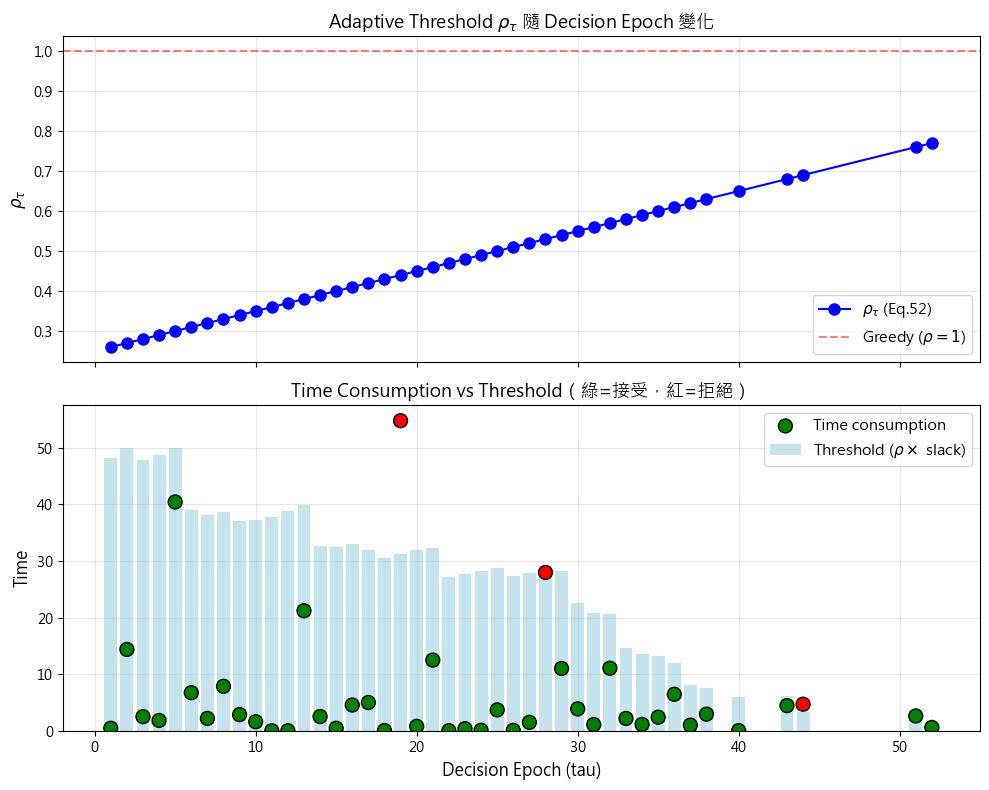

In [250]:
# ===== 5.7 rho 與 threshold 變化圖 =====

log = results_adaptive['decision_log']
# 只取有完整資料的 log
full_log = [l for l in log if ('rho' in l and 'time_consumption' in l and l['time_consumption'] is not None and 'threshold' in l and l['threshold'] is not None)]

if full_log:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    taus = [l['tau'] for l in full_log]
    rhos = [l['rho'] for l in full_log]
    times_consump = [l['time_consumption'] for l in full_log]
    thresholds = [l['threshold'] for l in full_log]
    accepted = [l['accepted'] for l in full_log]

    # 上圖：rho 隨 tau 變化
    ax1.plot(taus, rhos, 'b-o', markersize=8, label='$\\rho_\\tau$ (Eq.52)')
    ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Greedy ($\\rho=1$)')
    ax1.set_ylabel('$\\rho_\\tau$', fontsize=12)
    ax1.set_title('Adaptive Threshold $\\rho_\\tau$ 隨 Decision Epoch 變化', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)

    # 下圖：time_consumption vs threshold
    colors_pts = ['green' if a else 'red' for a in accepted]
    ax2.bar(taus, thresholds, color='lightblue', alpha=0.7, label='Threshold ($\\rho \\times$ slack)')
    ax2.scatter(taus, times_consump, c=colors_pts, s=100, zorder=5,
                edgecolors='black', label='Time consumption')
    ax2.set_xlabel('Decision Epoch (tau)', fontsize=12)
    ax2.set_ylabel('Time', fontsize=12)
    ax2.set_title('Time Consumption vs Threshold（綠=接受，紅=拒絕）', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Decision log 中沒有完整資料（可能所有訂單都在 insertion 階段被拒絕）')


## 5.8 Decision Timeline（訂單接受/拒絕時間軸）

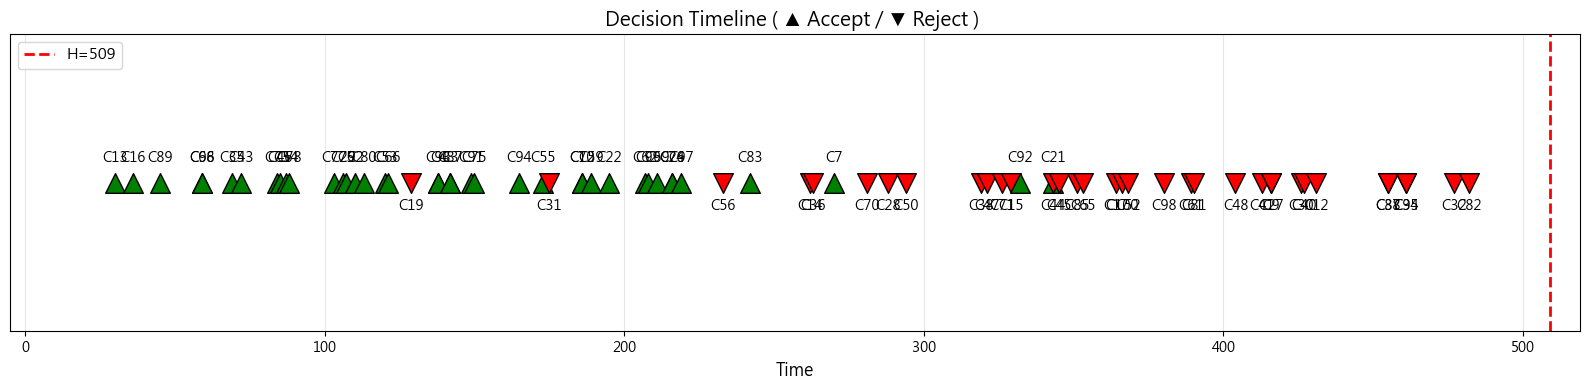

In [251]:
# ===== 5.8 Decision Timeline =====

fig, ax = plt.subplots(figsize=(16, 4))

for l in results_adaptive['decision_log']:
    color = 'green' if l['accepted'] else 'red'
    marker = '^' if l['accepted'] else 'v'
    ax.scatter(l['time'], 0, c=color, marker=marker, s=200, zorder=5, edgecolors='black')
    ax.annotate(f'C{l["order"]}', (l['time'], 0), textcoords="offset points",
                xytext=(0, 15 if l['accepted'] else -20), ha='center', fontsize=10)

# H 線
ax.axvline(x=inst['H'], color='red', linestyle='--', linewidth=2, label=f'H={inst["H"]:.0f}')

ax.set_xlabel('Time', fontsize=12)
ax.set_title('Decision Timeline ( ▲ Accept / ▼ Reject ) ', fontsize=14)
ax.set_yticks([])
ax.set_xlim(-5, inst['H'] + 10)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 5.9 Truck Route + Drone Meeting 空間視覺化（修正版）

注意：這張圖不是用 `final_state['visited_nodes'] + final_state['future_route']` 畫。  
因為 simulation 最後會把 truck state 推進到 \(H\)，此時 route 可能已經被清空，或只剩最後狀態；直接畫 final state 容易出現「把已拒絕節點也連進路線」或「顏色分類錯誤」的誤導。

本圖改用 `run_online_policy()` 中儲存的 `route_history[-1]` 作為 truck route，
並用 `final_state["realized_meetings"] + final_state["planned_sorties"]` 畫 drone meeting：

- 藍線：最後一次 **accepted decision** 後的完整 truck route snapshot。
- 紅色虛線：實際已發生或最後仍有效的 drone meeting。
- 節點顏色：依據 `initial_orders` 與 `dynamic_orders`，不是使用 raw release time `r` 判斷。
- 被接受的 dynamic order 另外用較粗外框標示。


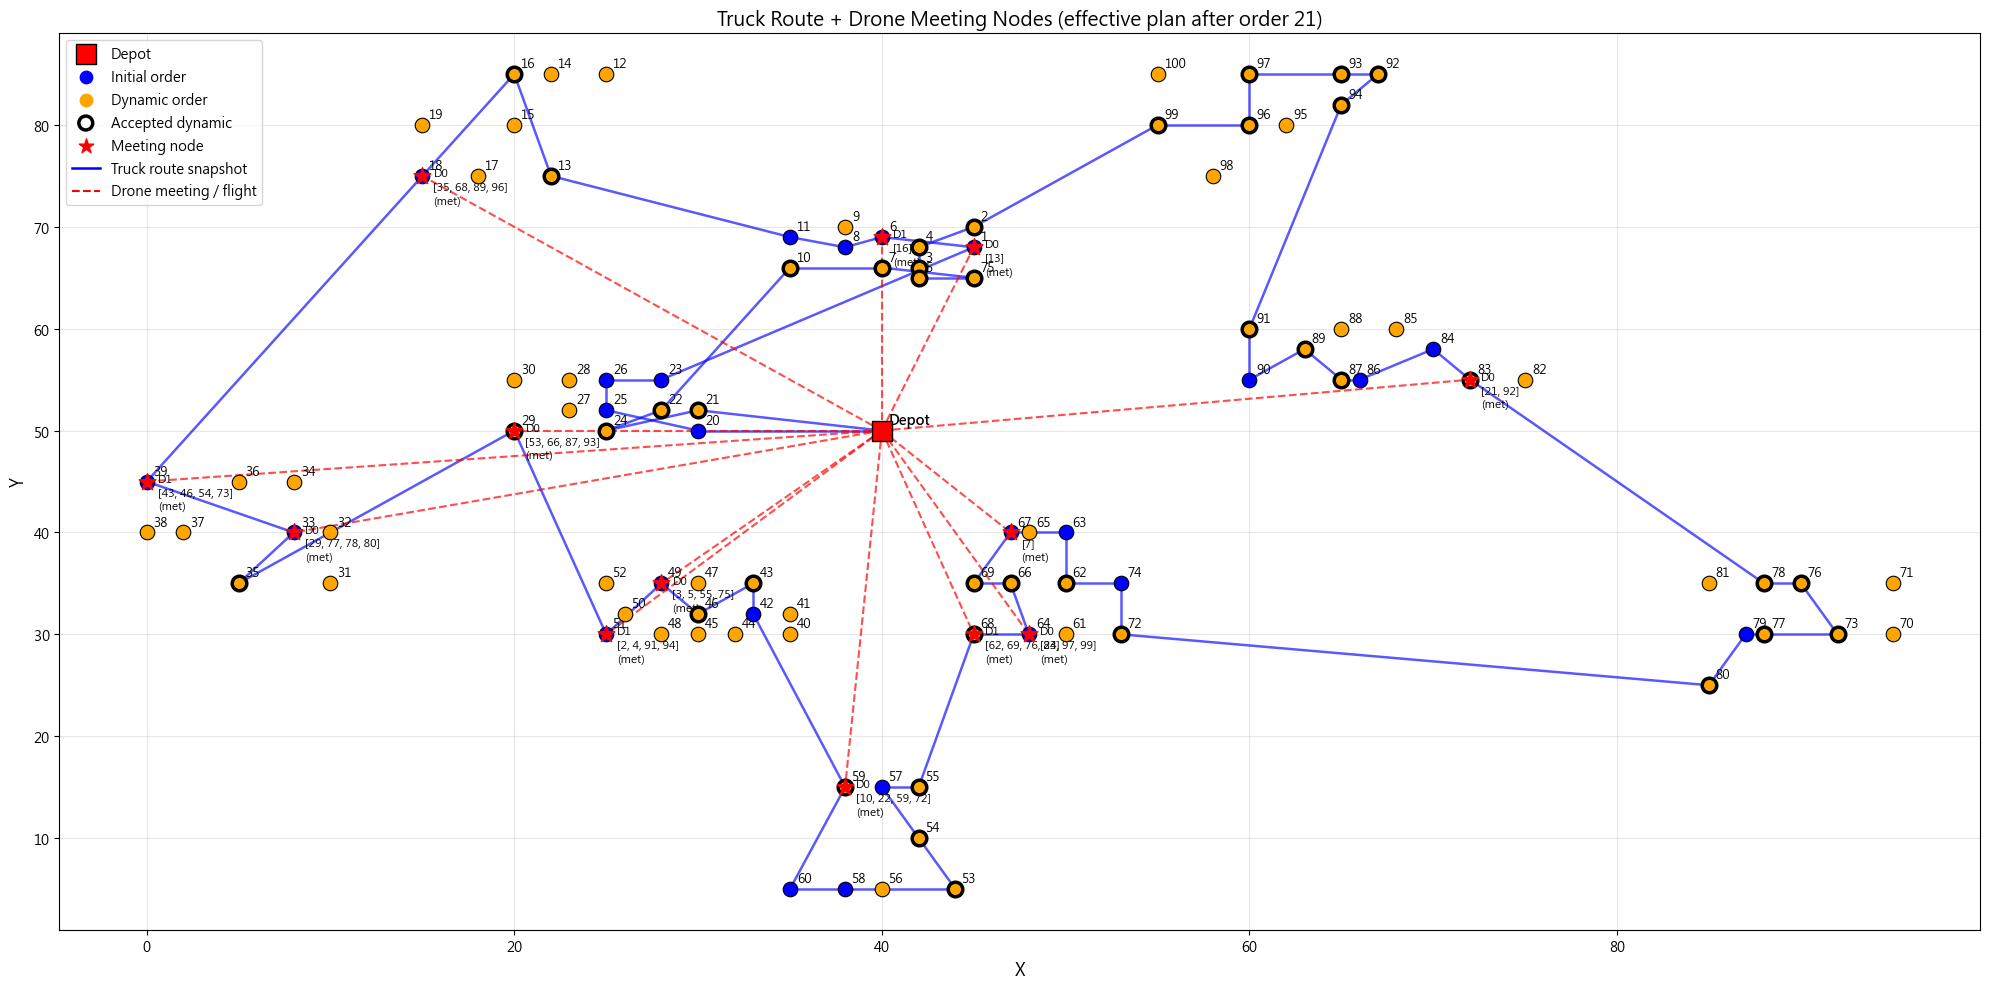

Visualization route snapshot: [0, 20, 25, 26, 23, 1, 6, 8, 11, 13, 16, 18, 39, 33, 35, 29, 51, 49, 46, 43, 42, 59, 60, 58, 53, 54, 57, 55, 68, 64, 66, 69, 67, 63, 62, 74, 72, 80, 79, 77, 73, 76, 78, 83, 84, 86, 87, 89, 90, 91, 94, 92, 93, 97, 96, 99, 2, 4, 3, 5, 75, 7, 10, 22, 24, 21, 0]
Accepted dynamic orders: [2, 3, 4, 5, 7, 10, 13, 16, 21, 22, 24, 29, 35, 43, 46, 53, 54, 55, 59, 62, 66, 68, 69, 72, 73, 75, 76, 77, 78, 80, 83, 87, 89, 91, 92, 93, 94, 96, 97, 99]
Realized meetings: [{'drone': 0, 'meeting_node': 1, 'meeting_time': 42.7860993661672, 'return_time': 52.1268702123019, 'orders': [13], 'source': 'realized'}, {'drone': 1, 'meeting_node': 6, 'meeting_time': 47.88511887975998, 'return_time': 57.38511887975998, 'orders': [16], 'source': 'realized'}, {'drone': 0, 'meeting_node': 18, 'meeting_time': 88.97966449538896, 'return_time': 106.65733402505265, 'orders': [35, 68, 89, 96], 'source': 'realized'}, {'drone': 1, 'meeting_node': 39, 'meeting_time': 122.52068415788577, 'return_t

In [252]:
# ===== 5.9 Route 視覺化（v9 修正版） =====
# 重點：
# 1. truck route 仍用最後一次 accepted plan snapshot，避免 final_state 被推進到 H 後 route 消失。
# 2. drone meeting 不再只看 last accepted snapshot；改用
#    final_state['realized_meetings'] + final_state['planned_sorties']，
#    因此已經在較早時間發生的 rendezvous 也會被畫出來。

inst_viz = setup_instance(test_file, zeta=1.0)
viz_results = run_online_policy(inst_viz, policy='adaptive', verbose=False)

route_snapshots = viz_results.get('route_history', [])
last_plan = route_snapshots[-1] if route_snapshots else {
    'route': [0] + list(viz_results['final_state'].get('future_route', [])),
    'planned_sorties': [],
    'accepted_dynamic': viz_results.get('accepted', []),
    'note': 'fallback'
}

plot_route = list(last_plan.get('route', []))
accepted_dynamic_set = set(viz_results.get('accepted', []))
initial_set = set(inst_viz['initial_orders'])
dynamic_set = set(inst_viz['dynamic_orders'])

final_state_viz = viz_results.get('final_state', {})
realized_meetings = list(final_state_viz.get('realized_meetings', []))
active_plans = []
for s in final_state_viz.get('planned_sorties', []):
    active_plans.append({
        'drone': s.get('drone'),
        'meeting_node': s.get('meeting_node'),
        'meeting_time': s.get('meeting_time'),
        'return_time': s.get('return_time'),
        'orders': list(s.get('orders', [])),
        'source': 'active_plan' if not s.get('transferred', False) else 'returning_after_meet'
    })

# Combine meetings. If a sortie has already met and is still returning,
# the realized_meetings entry should dominate the empty-orders returning copy.
combined_meetings = []
seen = set()
for m in realized_meetings + active_plans:
    key = (m.get('drone'), int(m.get('meeting_node')), round(float(m.get('meeting_time', 0.0)), 3))
    if key in seen:
        continue
    seen.add(key)
    combined_meetings.append(m)

fig, ax = plt.subplots(figsize=(20, 10))

nodes = [inst_viz['depot']] + inst_viz['customers']

# 所有 customer 節點
for c in inst_viz['customers']:
    node_id = int(c['id'])

    if node_id in initial_set:
        color = 'blue'
    elif node_id in dynamic_set:
        color = 'orange'
    else:
        color = 'gray'

    linewidth = 2.5 if node_id in accepted_dynamic_set else 0.8
    edgecolor = 'black'

    ax.scatter(c['x'], c['y'], c=color, s=110, zorder=5,
               edgecolors=edgecolor, linewidths=linewidth)
    ax.annotate(str(node_id), (c['x'], c['y']),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

# Depot
ax.scatter(inst_viz['depot']['x'], inst_viz['depot']['y'],
           c='red', s=200, marker='s', zorder=6,
           edgecolors='black', label='Depot')
ax.annotate('Depot', (inst_viz['depot']['x'], inst_viz['depot']['y']),
            textcoords="offset points", xytext=(5, 5),
            fontsize=10, fontweight='bold')

# Truck route snapshot
if len(plot_route) >= 2:
    for i in range(len(plot_route) - 1):
        n1, n2 = plot_route[i], plot_route[i + 1]
        ax.plot([nodes[n1]['x'], nodes[n2]['x']],
                [nodes[n1]['y'], nodes[n2]['y']],
                'b-', linewidth=1.8, alpha=0.65)

# Drone meetings: draw all realized + still-active meetings
for m in combined_meetings:
    m_node = int(m['meeting_node'])
    orders_txt = list(m.get('orders', []))
    src = m.get('source', '')

    ax.plot([inst_viz['depot']['x'], nodes[m_node]['x']],
            [inst_viz['depot']['y'], nodes[m_node]['y']],
            'r--', linewidth=1.5, alpha=0.7)
    ax.scatter(nodes[m_node]['x'], nodes[m_node]['y'],
               c='red', s=160, marker='*', zorder=7)

    if src == 'realized':
        tag = 'met'
    elif src == 'returning_after_meet':
        tag = 'return'
    else:
        tag = 'plan'

    ax.annotate(f"D{m['drone']}\n{orders_txt}\n({tag})",
                (nodes[m_node]['x'], nodes[m_node]['y']),
                textcoords="offset points", xytext=(8, -20), fontsize=8)

# Legend
ax.scatter([], [], c='blue', s=80, label='Initial order')
ax.scatter([], [], c='orange', s=80, label='Dynamic order')
ax.scatter([], [], facecolors='none', edgecolors='black', linewidths=2.5,
           s=100, label='Accepted dynamic')
ax.scatter([], [], c='red', s=120, marker='*', label='Meeting node')
ax.plot([], [], 'b-', linewidth=1.8, label='Truck route snapshot')
ax.plot([], [], 'r--', linewidth=1.5, label='Drone meeting / flight')

route_order = last_plan.get('order', None)
title_suffix = f"effective plan after order {route_order}" if route_order is not None else "initial route"

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'Truck Route + Drone Meeting Nodes ({title_suffix})', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Visualization route snapshot:', plot_route)
print('Accepted dynamic orders:', sorted(accepted_dynamic_set))
print('Realized meetings:', realized_meetings)
print('Active/remaining planned sorties:', active_plans)
print('Plotted meetings:', combined_meetings)


## Phase 5 總結（整合修正版）

### 已完成
- **5.1**：Lower Bound（Eq. 49）快速篩選
- **5.2**：`run_online_policy()` 完整 online policy
  - Adaptive（Eq. 52）：\(\rho_\tau = (|A^0|+\tau) / (|A^0|+E[\mathcal{T}])\)
  - Greedy：\(\rho = 1\)
  - 每個 decision epoch 執行：
    1. 推進 system state
    2. 計算 \(C(s^\tau)\)
    3. Cheapest insertion 產生 candidate route
    4. LB check
    5. DRP MILP 計算 \(C(s^{\tau,a})\)
    6. Threshold rule 決定 accept/reject
    7. Accept 時把 DRP plan 回寫到 state
- **State transition 已補強**
  - `A_depot`：還在 depot 等 drone 補給的 orders
  - `L_truck`：truck 上的 orders
  - `O_drone`：drone 正在攜帶的 orders
  - `planned_sorties`：已規劃 drone sorties
  - `route_schedule`：DRP 回寫的 truck departure schedule
- **DRP 已補 order-to-sortie assignment**
  - 每個 depot order 必須被某趟 sortie 補給
  - meeting position 必須早於或等於該 order 在 route 中的位置

### 本 notebook 仍未完整包含的論文內容
1. Perfect-information upper bound / OPRD-DR（論文 Section 4）
2. 多 distribution 大規模實驗：C101、C201、R101、RC101、100 customers
3. Drone resupply vs truck-based resupply benchmark
4. 更精細的 in-transit drone handling（本版採「未起飛可重規劃，已起飛不可撤銷」的簡化處理）


### v5 補強內容

本版已補齊 in-transit planned sortie 的處理：

- 未起飛 sortie：可取消並由下一次 DRP 重新規劃。
- 已起飛未會合 sortie：不可撤銷，作為 fixed sortie 保留。
- Candidate insertion：若存在 fixed sortie，新訂單只能插入 rendezvous node 之後。
- DRP MILP：加入 fixed rendezvous timing，下次求解不得讓 truck 在該 rendezvous 前改路或提前離開。
- State update：已會合但 drone 尚未返回 depot 的 sortie 以 `transferred=True` 保留，避免 orders 重複加入 `L_truck`。
